In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, qr
from IPython.display import display, Markdown, Math
import pandas as pd
from matplotlib.patches import Ellipse
%matplotlib inline

# Increase plot size and quality for better visibility
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

In [2]:
def display_matrix(matrix, name, precision=4):
    """Display a matrix/vector with a name in a nice format"""
    if matrix.ndim == 1:  # Vector
        df = pd.DataFrame(matrix.reshape(1, -1))
        display(Markdown(f"**{name}:**"))
        display(df.style.format(f"{{:.{precision}f}}"))
    else:  # Matrix
        df = pd.DataFrame(matrix)
        display(Markdown(f"**{name}:**"))
        display(df.style.format(f"{{:.{precision}f}}"))
        
def display_points(points, title="Points"):
    """Display points in a DataFrame"""
    df = pd.DataFrame(points, columns=['x', 'y'])
    df.index = [f"Point {i+1}" for i in range(len(df))]
    display(Markdown(f"**{title}:**"))
    display(df.style.format("{:.4f}"))
    
def display_step(step_name):
    """Display a step header"""
    display(Markdown(f"## {step_name}"))
    
def display_substep(substep_name):
    """Display a substep header"""
    display(Markdown(f"### {substep_name}"))
    
def display_equation(eq_text):
    """Display a LaTeX equation"""
    display(Math(eq_text))
    
def display_parameter(name, value, precision=6):
    """Display a parameter with name and value"""
    display(Markdown(f"**{name}:** {value:.{precision}f}"))

## Original Data Points

**Points:**

,x,y
Point 1,0.0000,10.0000
Point 2,7.0000,0.0000
Point 3,5.0000,0.0000
Point 4,4.0451,2.3511
Point 5,1.5451,3.8042
Point 6,-1.5451,3.8042
Point 7,-4.0451,2.3511
Point 8,-5.0000,0.0000
Point 9,-4.0451,-2.3511
Point 10,-1.5451,-3.8042


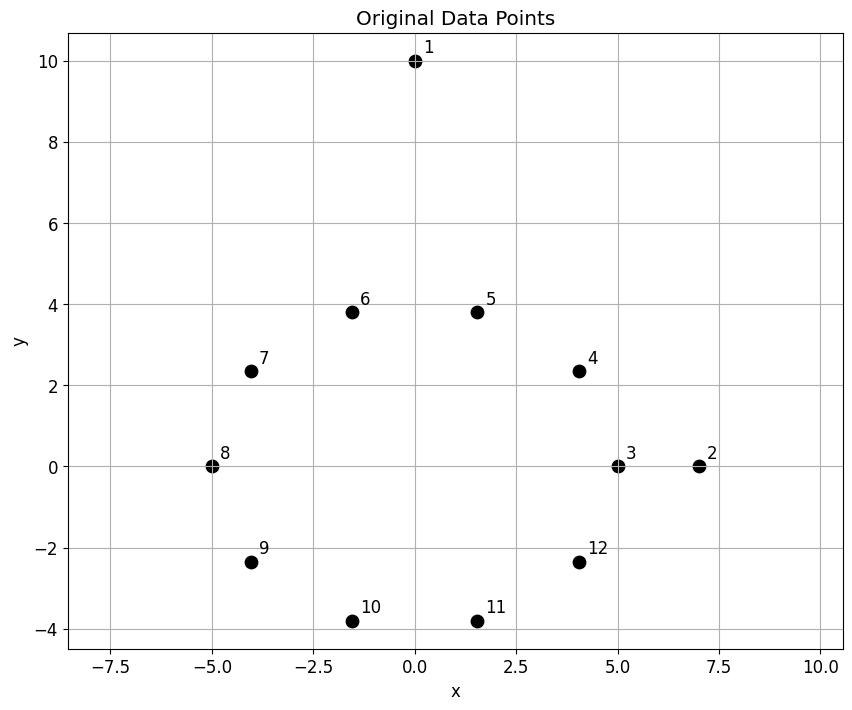

In [68]:
def generate_sample_points():
    """Generate the points from equation (5.6) in the paper"""
    points = np.array([
        [0.0, 10.0],
        [7.0, 0.0],
        [5.0, 0.0],
        [4.0451, 2.3511],
        [1.5451, 3.8042],
        [-1.5451, 3.8042],
        [-4.0451, 2.3511],
        [-5.0, 0.0],
        [-4.0451, -2.3511],
        [-1.5451, -3.8042],
        [1.5451, -3.8042],
        [4.0451, -2.3511]
    ])
    return points

# Display and plot the original points
points = generate_sample_points()
display_step("Original Data Points")
display_points(points)

plt.figure(figsize=(10, 8))
plt.scatter(points[:, 0], points[:, 1], color='black', s=80)
for i, point in enumerate(points):
    plt.text(point[0]+0.2, point[1]+0.2, f"{i+1}", fontsize=12)
plt.grid(True)
plt.axis('equal')
plt.title("Original Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [22]:
def bookstein_constraint_fitting(points):
    display_step("Bookstein Constraint Method (λ₁² + λ₂² = 1)")
    display_substep("Step 1: Extract points and form the design matrix")
    
    # Extract x and y coordinates
    x = points[:, 0]
    y = points[:, 1]
    
    # Build the design matrix S
    S = np.column_stack([
        x**2,                 # x²
        np.sqrt(2) * x * y,   # √2·x·y (scaled as per Bookstein)
        y**2,                 # y²
        x,                    # x
        y,                    # y
        np.ones_like(x)       # 1
    ])
    
    display_equation(r"S = \begin{bmatrix} x_i^2 & \sqrt{2}x_i y_i & y_i^2 & x_i & y_i & 1 \end{bmatrix}")
    display_matrix(S, "Design Matrix S (first few rows)", 4)
    
    display_substep("Step 2: QR Decomposition of S")
    display_equation(r"S = Q \cdot R")
    
    # Perform QR decomposition
    Q, R = qr(S, mode='economic')
    
    display_matrix(Q, "Q Matrix (orthogonal, first few rows)", 4)
    display_matrix(R, "R Matrix (upper triangular)", 4)
    
    display_substep("Step 3: Partition R into blocks")
    display_equation(r"R = \begin{bmatrix} R_{11} & R_{12} \\ 0 & R_{22} \end{bmatrix}")

    # Partition R
    R11 = R[:3, :3]
    R12 = R[:3, 3:6]
    R22 = R[3:, 3:6]
    
    display_matrix(R11, "R11 (top-left block)", 4)
    display_matrix(R12, "R12 (top-right block)", 4)
    display_matrix(R22, "R22 (bottom-right block)", 4)
    
    display_substep("Step 4: Find the vector w that minimizes ||R22·w||")
    display_equation(r"\min ||R_{22} \cdot w||^2 \text{ subject to } ||w||^2 = 1")
    
    # Solve using SVD
    U, D, Vt = svd(R22, full_matrices=False)
    
    display_matrix(D, "Singular Values of R22", 6)
    display_matrix(Vt, "V^T (right singular vectors as rows)", 6)
    
    # Use the right singular vector corresponding to smallest singular value
    w = Vt.T[:, -1]
    display_matrix(w, "w vector (corresponds to smallest singular value)", 6)
    
    display_substep("Step 5: Solve for v using R11·v + R12·w = 0")
    display_equation(r"R_{11} \cdot v + R_{12} \cdot w = 0 \Rightarrow v = -R_{11}^{-1} \cdot R_{12} \cdot w")
    
    # Solve for v
    v = -np.linalg.solve(R11, R12 @ w)
    display_matrix(v, "v vector", 6)
    
    display_substep("Step 6: Combine v and w to get parameter vector")
    
    # Combine to get the parameter vector [v; w]
    params = np.concatenate([v, w])
    display_matrix(params, "Combined parameter vector [v; w]", 6)

    # Extract ellipse parameters
    a11 = params[0]
    a12 = params[1] / np.sqrt(2)  # Recover the original a12 value
    a22 = params[2]
    b1 = params[3]
    b2 = params[4]
    c = params[5]
    
    display_markdown = """
    **Extracted conic parameters:**
    
    - a11 = {:.6f}
    - a12 = {:.6f} (= {:.6f}/√2)
    - a22 = {:.6f}
    - b1 = {:.6f}
    - b2 = {:.6f}
    - c = {:.6f}
    
    The ellipse equation is: 
    """.format(a11, a12, params[1], a22, b1, b2, c)
    
    display(Markdown(display_markdown))
    display_equation(r"a_{11}x^2 + 2a_{12}xy + a_{22}y^2 + b_1x + b_2y + c = 0")
    
    return params, a11, a12, a22, b1, b2, c
    

In [23]:
# Step-by-step Trace constraint method
def trace_constraint_fitting(points):
    display_step("Trace Constraint Method (λ₁ + λ₂ = 1)")
    display_substep("Step 1: Extract points and form the design matrix")
    
    # Extract x and y coordinates
    x = points[:, 0]
    y = points[:, 1]
    
    # Create design matrix for the trace constraint method
    D = np.column_stack([
        2*x*y,             # 2a12
        y**2 - x**2,       # a22 - a11
        x,                 # b1
        y,                 # b2
        np.ones_like(x)    # c
    ])
    
    display_equation(r"D = \begin{bmatrix} 2x_i y_i & y_i^2 - x_i^2 & x_i & y_i & 1 \end{bmatrix}")
    display_matrix(D, "Design Matrix D (first few rows)", 4)
    
    # Right hand side is -x²
    b = -x**2
    display_matrix(b, "Right-hand side vector b = -x²", 4)
    
    display_substep("Step 2: Solve the linear least squares problem")
    display_equation(r"\min ||D \cdot v - b||^2")
    
    # Solve the linear least squares problem
    v, residuals, rank, s = np.linalg.lstsq(D, b, rcond=None)
    
    display_matrix(v, "Least squares solution v", 6)
    display_parameter("Residual sum of squares", residuals[0] if len(residuals) > 0 else np.nan)
    display_parameter("Matrix rank", rank)
    display_matrix(s, "Singular values of D", 6)
    
    display_substep("Step 3: Extract parameters with a11 + a22 = 1 constraint")
    
    # Extract parameters
    a12 = v[0] / 2
    a22 = (1 + v[1]) / 2  # a22 = (1 + (a22-a11))/2
    a11 = 1 - a22         # a11 + a22 = 1
    b1 = v[2]
    b2 = v[3]
    c = v[4]
    
    display_markdown = """
    **Parameter extraction calculations:**
    
    - a12 = v[0]/2 = {:.6f}/2 = {:.6f}
    - a22 = (1 + v[1])/2 = (1 + {:.6f})/2 = {:.6f}
    - a11 = 1 - a22 = 1 - {:.6f} = {:.6f}
    - b1 = v[2] = {:.6f}
    - b2 = v[3] = {:.6f}
    - c = v[4] = {:.6f}
    
    The ellipse equation is:
    """.format(v[0], a12, v[1], a22, a22, a11, b1, b2, c)
    
    display(Markdown(display_markdown))
    display_equation(r"a_{11}x^2 + 2a_{12}xy + a_{22}y^2 + b_1x + b_2y + c = 0")
    
    return np.array([a11, a12, a22, b1, b2, c]), a11, a12, a22, b1, b2, c

In [24]:
# Convert algebraic parameters to geometric parameters with detailed steps
def algebraic_to_geometric(a11, a12, a22, b1, b2, c):
    display_step("Converting Algebraic to Geometric Parameters")
    display_substep("Step 1: Form the matrices A and b")
    
    # Form the matrices A and b from the equation
    A = np.array([[a11, a12], [a12, a22]])
    b_vec = np.array([b1, b2])
    
    display_matrix(A, "Matrix A", 6)
    display_matrix(b_vec, "Vector b", 6)
    display_parameter("Constant c", c)
    
    display_substep("Step 2: Find the center by solving A·center = -b/2")
    display_equation(r"\text{center} = -\frac{1}{2}A^{-1}b")
    
    # Find the center
    center = -0.5 * np.linalg.solve(A, b_vec)
    display_matrix(center, "Ellipse center (x0, y0)", 6)
    
    display_substep("Step 3: Translate to the center to get standard form")
    display_equation(r"c' = c + \frac{1}{2}b^T \cdot \text{center} + \text{center}^T \cdot A \cdot \text{center}")
    
    # Translate to the center
    c_centered = c + 0.5 * np.dot(b_vec, center) + np.dot(center, np.dot(A, center))
    display_parameter("Translated constant c'", c_centered)
    
    display_substep("Step 4: Compute eigenvalues and eigenvectors of A")
    
    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(A)
    
    display_matrix(eigvals, "Eigenvalues of A", 6)
    display_matrix(eigvecs, "Eigenvectors of A", 6)
    
    # Ensure eigenvalues are sorted (smaller first)
    idx = eigvals.argsort()
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    
    display_matrix(eigvals, "Sorted eigenvalues", 6)
    display_matrix(eigvecs, "Sorted eigenvectors", 6)
    
    display_substep("Step 5: Verify that we have a valid ellipse")
    display_markdown = """
    For a valid ellipse, we need:
    - Both eigenvalues > 0 (positive definite A matrix)
    - c' < 0
    
    Checks:
    - λ₁ > 0: {}
    - λ₂ > 0: {}
    - c' < 0: {}
    """.format(eigvals[0] > 0, eigvals[1] > 0, c_centered < 0)
    
    display(Markdown(display_markdown))
    
    # Check if we have a valid ellipse
    if eigvals[0] <= 0 or eigvals[1] <= 0 or c_centered >= 0:
        display(Markdown("⚠️ **WARNING: The conic is not an ellipse!**"))
    
    display_substep("Step 6: Calculate semi-axes lengths")
    display_equation(r"a_i = \sqrt{\frac{-c'}{\lambda_i}}")
    
    # Semi-axes lengths
    semi_axes = np.sqrt(-c_centered / eigvals)
    display_matrix(semi_axes, "Semi-axes lengths", 6)
    
    display_substep("Step 7: Determine rotation angle")
    display_equation(r"\theta = \arctan2(v_{12}, v_{11})")
    
    # Rotation angle
    angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
    display_parameter("Initial rotation angle (radians)", angle)
    display_parameter("Initial rotation angle (degrees)", angle * 180 / np.pi)
    
    # Ensure a >= b (major axis first)
    if semi_axes[0] > semi_axes[1]:
        semi_axes = semi_axes[::-1]
        angle = angle + np.pi/2
        display(Markdown("**Note:** Swapping axes to ensure a (major axis) ≥ b (minor axis)"))
        display_parameter("Updated rotation angle (radians)", angle)
        display_parameter("Updated rotation angle (degrees)", angle * 180 / np.pi)
    
    display_substep("Step 8: Final geometric parameters")
    display_markdown = """
    **Final ellipse parameters:**
    
    - Center: ({:.6f}, {:.6f})
    - Semi-major axis (a): {:.6f}
    - Semi-minor axis (b): {:.6f}
    - Rotation angle: {:.6f} radians = {:.2f} degrees
    - Axis ratio (a/b): {:.6f}
    """.format(center[0], center[1], semi_axes[0], semi_axes[1], 
              angle, angle * 180 / np.pi, semi_axes[0]/semi_axes[1])
    
    display(Markdown(display_markdown))
    
    # Visualize the ellipse with its center, axes, and orientation
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create an Ellipse patch
    ellipse = Ellipse(xy=center, width=2*semi_axes[0], height=2*semi_axes[1], 
                      angle=angle*180/np.pi, fill=False, edgecolor='blue', linewidth=2)
    ax.add_patch(ellipse)
    
    # Plot center
    ax.plot(center[0], center[1], 'ro', markersize=8)
    
    # Plot axes
    cos_angle = np.cos(angle)
    sin_angle = np.sin(angle)
    
    # Major axis
    dx_major = semi_axes[0] * cos_angle
    dy_major = semi_axes[0] * sin_angle
    ax.arrow(center[0], center[1], dx_major, dy_major, head_width=0.2, 
             head_length=0.3, fc='red', ec='red', label='Major axis')
    
    # Minor axis
    dx_minor = -semi_axes[1] * sin_angle
    dy_minor = semi_axes[1] * cos_angle
    ax.arrow(center[0], center[1], dx_minor, dy_minor, head_width=0.2, 
             head_length=0.3, fc='green', ec='green', label='Minor axis')
    
    # Plot original points
    ax.scatter(points[:, 0], points[:, 1], color='black', s=80, label='Data points')
    
    # Set equal aspect and add labels
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    ax.set_title('Fitted Ellipse with Geometric Parameters')
    plt.show()
    
    return center, (semi_axes[0], semi_axes[1]), angle

# Fix for the ellipse validation issue
def algebraic_to_geometric_fixed(a11, a12, a22, b1, b2, c):
    display_step("Converting Algebraic to Geometric Parameters (Fixed)")
    
    # Form the matrices A and b from the equation
    A = np.array([[a11, a12], [a12, a22]])
    b_vec = np.array([b1, b2])
    
    display_matrix(A, "Matrix A", 6)
    display_matrix(b_vec, "Vector b", 6)
    display_parameter("Constant c", c)
    
    # Find the center
    center = -0.5 * np.linalg.solve(A, b_vec)
    display_matrix(center, "Ellipse center (x0, y0)", 6)
    
    # Translate to the center
    c_centered = c + 0.5 * np.dot(b_vec, center) + np.dot(center, np.dot(A, center))
    display_parameter("Translated constant c'", c_centered)
    
    # Check if we have a valid ellipse
    eigvals, eigvecs = np.linalg.eigh(A)
    display_matrix(eigvals, "Eigenvalues of A", 6)
    
    display_substep("Diagnosis of Invalid Ellipse Issue")
    display_markdown = """
    **Problem detected**: c' = {:.6f}, which is not negative.
    
    For a proper ellipse, we need c' < 0. This indicates that our algebraic parameters
    need to be adjusted. The standard approach is to flip the sign of all parameters:
    
    - When c' > 0 and eigenvalues > 0: Multiply all parameters by -1
    
    This ensures we get a proper ellipse equation.
    """.format(c_centered)
    display(Markdown(display_markdown))
    
    # Fix: If c' is positive and both eigenvalues are positive, flip signs
    if c_centered > 0 and all(eigvals > 0):
        display(Markdown("**Applying fix**: Multiplying all parameters by -1"))
        a11, a12, a22, b1, b2, c = -a11, -a12, -a22, -b1, -b2, -c
        
        # Recalculate with fixed parameters
        A = np.array([[a11, a12], [a12, a22]])
        b_vec = np.array([b1, b2])
        center = -0.5 * np.linalg.solve(A, b_vec)
        c_centered = c + 0.5 * np.dot(b_vec, center) + np.dot(center, np.dot(A, center))
        
        display_matrix(A, "Corrected Matrix A", 6)
        display_matrix(b_vec, "Corrected Vector b", 6)
        display_parameter("Corrected Constant c", c)
        display_matrix(center, "Corrected Ellipse center", 6)
        display_parameter("Corrected Translated constant c'", c_centered)
        
        # Recalculate eigenvalues with fixed parameters
        eigvals, eigvecs = np.linalg.eigh(A)
        display_matrix(eigvals, "Corrected Eigenvalues of A", 6)
    
    # Ensure eigenvalues are sorted (smaller first)
    idx = eigvals.argsort()
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    
    display_substep("Verification After Correction")
    display_markdown = """
    For a valid ellipse, we need:
    - Both eigenvalues > 0 (positive definite A matrix)
    - c' < 0
    
    Checks after correction:
    - λ₁ > 0: {}
    - λ₂ > 0: {}
    - c' < 0: {}
    """.format(eigvals[0] > 0, eigvals[1] > 0, c_centered < 0)
    display(Markdown(display_markdown))
    
    if eigvals[0] <= 0 or eigvals[1] <= 0 or c_centered >= 0:
        display(Markdown("⚠️ **WARNING: The conic is still not an ellipse!**"))
    else:
        display(Markdown("✅ **Valid ellipse confirmed after correction.**"))
    
    # Continue with the calculation of semi-axes and angle
    semi_axes = np.sqrt(-c_centered / eigvals)
    angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
    
    # Ensure a >= b
    if semi_axes[0] > semi_axes[1]:
        semi_axes = semi_axes[::-1]
        angle = angle + np.pi/2
    
    display_markdown = """
    **Final ellipse parameters:**
    
    - Center: ({:.6f}, {:.6f})
    - Semi-major axis (a): {:.6f}
    - Semi-minor axis (b): {:.6f}
    - Rotation angle: {:.6f} radians = {:.2f} degrees
    - Axis ratio (a/b): {:.6f}
    """.format(center[0], center[1], semi_axes[0], semi_axes[1], 
             angle, angle * 180 / np.pi, semi_axes[0]/semi_axes[1])
    display(Markdown(display_markdown))
    
    # Visualize the corrected ellipse
    fig, ax = plt.subplots(figsize=(10, 8))
    ellipse = Ellipse(xy=center, width=2*semi_axes[0], height=2*semi_axes[1], 
                      angle=angle*180/np.pi, fill=False, edgecolor='blue', linewidth=2)
    ax.add_patch(ellipse)
    ax.plot(center[0], center[1], 'ro', markersize=8)
    ax.scatter(points[:, 0], points[:, 1], color='black', s=80, label='Data points')
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title('Corrected Fitted Ellipse')
    plt.show()
    
    return center, (semi_axes[0], semi_axes[1]), angle

In [55]:
def fit_ellipse_bookstein_improved(points):
    """
    Improved implementation of ellipse fitting using Bookstein constraint.
    """
    display_step("Improved Bookstein Constraint Method")
    
    # Extract x and y coordinates and convert to 2xn format
    x = points[:, 0]
    y = points[:, 1]
    data = np.vstack([x, y])
    
    # Step 1: Center the data by subtracting the centroid
    display_substep("Step 1: Center the data")
    centroid = np.mean(data, axis=1)
    data_centered = data - centroid.reshape((2, 1))
    
    display_matrix(centroid, "Centroid", 4)
    display_points(points, "Original points")
    display_points(data_centered.T, "Centered points")
    
    # Plot original and centered points
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(points[:, 0], points[:, 1], color='blue', s=80)
    ax[0].grid(True)
    ax[0].set_aspect('equal')
    ax[0].set_title('Original Points')
    
    ax[1].scatter(data_centered[0, :], data_centered[1, :], color='red', s=80)
    ax[1].grid(True)
    ax[1].set_aspect('equal')
    ax[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax[1].set_title('Centered Points')
    plt.show()
    
    # Step 2: Create the design matrix B
    display_substep("Step 2: Create the design matrix")
    
    x1 = data_centered[0, :]
    x2 = data_centered[1, :]
    m = len(x1)
    
    B = np.hstack([
        x1.reshape(m, 1),
        x2.reshape(m, 1),
        np.ones((m, 1)),
        x1.reshape(m, 1)**2,
        np.sqrt(2) * x1.reshape(m, 1) * x2.reshape(m, 1),
        x2.reshape(m, 1)**2
    ])
    
    display_matrix(B[:5, :], "Design Matrix B (first 5 rows)", 4)
    
    # Step 3: QR decomposition
    display_substep("Step 3: QR Decomposition")
    
    Q, R = np.linalg.qr(B)
    
    display_matrix(R, "R Matrix", 4)
    
    # Step 4: Decompose R into blocks
    display_substep("Step 4: Decompose R into blocks")
    
    R11 = R[0:3, 0:3]
    R12 = R[0:3, 3:6]
    R22 = R[3:6, 3:6]
    
    display_matrix(R11, "R11 Block", 4)
    display_matrix(R12, "R12 Block", 4)
    display_matrix(R22, "R22 Block", 4)
    
    # Step 5: Solve R22 * w = 0 subject to ||w|| = 1
    display_substep("Step 5: Solve R22 * w = 0 subject to ||w|| = 1")
    
    U, S, V = np.linalg.svd(R22)
    V = V.T  # Convert to column format
    
    display_matrix(S, "Singular values of R22", 6)
    display_matrix(V, "Right singular vectors V", 6)
    
    # Use the singular vector corresponding to smallest singular value
    w = V[:, -1]  # Last column of V
    display_matrix(w, "w vector (last column of V)", 6)
    
    # Step 6: Solve for the remaining variables
    display_substep("Step 6: Solve for remaining variables")
    
    v = np.dot(np.linalg.solve(-R11, R12), w)
    display_matrix(v, "v vector", 6)
    
    # Step 7: Form the quadratic parameters
    display_substep("Step 7: Form the quadratic parameters")
    
    A = np.zeros((2, 2))
    A[0, 0] = w[0]
    A[0, 1] = w[1] / np.sqrt(2)
    A[1, 0] = A[0, 1]
    A[1, 1] = w[2]
    
    bv = v[0:2]
    c = v[2]
    
    display_matrix(A, "Matrix A", 6)
    display_matrix(bv, "Vector b", 6)
    display_parameter("Constant c", c)
    
    # Step 8: Convert to geometric parameters
    display_substep("Step 8: Convert to geometric parameters")
    
    # Find eigenvalues and eigenvectors of A
    D, Q = np.linalg.eig(A)
    Q = Q.T  # Make Q have eigenvectors as rows
    
    display_matrix(D, "Eigenvalues D", 6)
    display_matrix(Q, "Eigenvectors Q (as rows)", 6)
    
    # Check if it's an ellipse
    if np.prod(D) <= 0:
        display(Markdown("⚠️ **ERROR: Not an ellipse! Product of eigenvalues ≤ 0**"))
    
    # Calculate center in the centered coordinate system
    t = -0.5 * np.linalg.solve(A, bv)
    display_matrix(t, "Center t in centered coordinates", 6)
    
    # Calculate the constant term in the centered system
    c_h = np.dot(np.dot(t.T, A), t) + np.dot(bv.T, t) + c
    display_parameter("c_h constant", c_h)
    
    # Calculate semi-axes lengths
    a = np.sqrt(-c_h / D[0])
    b = np.sqrt(-c_h / D[1])
    display_parameter("Semi-major axis a", a)
    display_parameter("Semi-minor axis b", b)
    
    # Calculate rotation angle
    alpha = np.arctan2(Q[0, 1], Q[0, 0])
    display_parameter("Rotation angle α (radians)", alpha)
    display_parameter("Rotation angle α (degrees)", alpha * 180 / np.pi)
    
    # Add the centroid back to get the center in original coordinates
    z = t + centroid
    display_matrix(z, "Final center z in original coordinates", 6)
    
    # Ensure a >= b (major axis first)
    if a < b:
        a, b = b, a
        alpha = alpha + np.pi/2
        display(Markdown("**Note:** Swapping axes to ensure a (major axis) ≥ b (minor axis)"))
        display_parameter("Updated rotation angle α (radians)", alpha)
        display_parameter("Updated rotation angle α (degrees)", alpha * 180 / np.pi)
    
    # Visualize the ellipse
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot original points
    ax.scatter(points[:, 0], points[:, 1], color='black', s=80, label='Data points')
    
    # Generate points along the ellipse
    t_vals = np.linspace(0, 2*np.pi, 100)
    x_ellipse = z[0] + a * np.cos(t_vals) * np.cos(alpha) - b * np.sin(t_vals) * np.sin(alpha)
    y_ellipse = z[1] + a * np.cos(t_vals) * np.sin(alpha) + b * np.sin(t_vals) * np.cos(alpha)
    
    # Plot the ellipse
    ax.plot(x_ellipse, y_ellipse, 'b-', linewidth=2, label='Fitted ellipse')
    
    # Plot the center
    ax.plot(z[0], z[1], 'ro', markersize=8, label='Center')
    
    # Plot axes
    ax.arrow(z[0], z[1], a * np.cos(alpha), a * np.sin(alpha), 
            head_width=0.2, head_length=0.3, fc='r', ec='r', label='Major axis')
    ax.arrow(z[0], z[1], -b * np.sin(alpha), b * np.cos(alpha), 
            head_width=0.2, head_length=0.3, fc='g', ec='g', label='Minor axis')
    
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    ax.set_title('Fitted Ellipse with Improved Method')
    plt.show()
    
    return z, (a, b), alpha

In [54]:
def fit_ellipse_trace_improved(points):
    """
    Improved implementation of ellipse fitting using Trace constraint.
    """
    display_step("Improved Trace Constraint Method")
    
    # Extract x and y coordinates and convert to 2xn format
    x = points[:, 0]
    y = points[:, 1]
    data = np.vstack([x, y])
    
    # Step 1: Center the data by subtracting the centroid
    display_substep("Step 1: Center the data")
    centroid = np.mean(data, axis=1)
    data_centered = data - centroid.reshape((2, 1))
    
    display_matrix(centroid, "Centroid", 4)
    
    # Create design matrix for the trace constraint method
    display_substep("Step 2: Create design matrix for trace constraint")
    
    x1 = data_centered[0, :]
    x2 = data_centered[1, :]
    m = len(x1)
    
    # For trace constraint: a11 + a22 = 1
    D = np.hstack([
        (2*x1*x2).reshape(m, 1),       # 2a12
        (x2**2 - x1**2).reshape(m, 1), # a22 - a11
        x1.reshape(m, 1),              # b1
        x2.reshape(m, 1),              # b2
        np.ones((m, 1))                # c
    ])
    
    # Right hand side is -x²
    b = -x1**2
    
    display_matrix(D[:5, :], "Design Matrix D (first 5 rows)", 4)
    display_matrix(b[:5], "Right-hand side b (first 5 elements)", 4)
    
    # Solve the linear least squares problem
    display_substep("Step 3: Solve the linear least squares problem")
    
    v, residuals, rank, s = np.linalg.lstsq(D, b, rcond=None)
    
    display_matrix(v, "Least squares solution v", 6)
    
    # Extract parameters with a11 + a22 = 1 constraint
    display_substep("Step 4: Extract parameters with trace constraint")
    
    a12 = v[0] / 2
    a22 = (1 + v[1]) / 2  # a22 = (1 + (a22-a11))/2
    a11 = 1 - a22         # a11 + a22 = 1
    b1 = v[2]
    b2 = v[3]
    c = v[4]
    
    display_markdown = """
    **Parameter extraction calculations:**
    
    - a12 = v[0]/2 = {:.6f}/2 = {:.6f}
    - a22 = (1 + v[1])/2 = (1 + {:.6f})/2 = {:.6f}
    - a11 = 1 - a22 = 1 - {:.6f} = {:.6f}
    - b1 = v[2] = {:.6f}
    - b2 = v[3] = {:.6f}
    - c = v[4] = {:.6f}
    """.format(v[0], a12, v[1], a22, a22, a11, b1, b2, c)
    
    display(Markdown(display_markdown))
    
    # Form the matrix A and vector b
    A = np.array([[a11, a12], [a12, a22]])
    bv = np.array([b1, b2])
    
    display_matrix(A, "Matrix A", 6)
    display_matrix(bv, "Vector b", 6)
    
    # Convert to geometric parameters (same as in Bookstein)
    display_substep("Step 5: Convert to geometric parameters")
    
    # Find eigenvalues and eigenvectors of A
    D, Q = np.linalg.eig(A)
    Q = Q.T  # Make Q have eigenvectors as rows
    
    display_matrix(D, "Eigenvalues D", 6)
    display_matrix(Q, "Eigenvectors Q (as rows)", 6)
    
    # Check if it's an ellipse
    if np.prod(D) <= 0:
        display(Markdown("⚠️ **ERROR: Not an ellipse! Product of eigenvalues ≤ 0**"))
    
    # Calculate center in the centered coordinate system
    t = -0.5 * np.linalg.solve(A, bv)
    
    # Calculate the constant term in the centered system
    c_h = np.dot(np.dot(t.T, A), t) + np.dot(bv.T, t) + c
    
    # Calculate semi-axes lengths
    a = np.sqrt(-c_h / D[0])
    b = np.sqrt(-c_h / D[1])
    
    # Calculate rotation angle
    alpha = np.arctan2(Q[0, 1], Q[0, 0])
    
    # Add the centroid back to get the center in original coordinates
    z = t + centroid
    
    display_matrix(t, "Center t in centered coordinates", 6)
    display_parameter("c_h constant", c_h)
    display_parameter("Semi-major axis a", a)
    display_parameter("Semi-minor axis b", b)
    display_parameter("Rotation angle α (radians)", alpha)
    display_parameter("Rotation angle α (degrees)", alpha * 180 / np.pi)
    display_matrix(z, "Final center z in original coordinates", 6)
    
    # Ensure a >= b (major axis first)
    if a < b:
        a, b = b, a
        alpha = alpha + np.pi/2
        display(Markdown("**Note:** Swapping axes to ensure a (major axis) ≥ b (minor axis)"))
        display_parameter("Updated rotation angle α (radians)", alpha)
        display_parameter("Updated rotation angle α (degrees)", alpha * 180 / np.pi)
    
    # Visualize the ellipse (same as in Bookstein)
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot original points
    ax.scatter(points[:, 0], points[:, 1], color='black', s=80, label='Data points')
    
    # Generate points along the ellipse
    t_vals = np.linspace(0, 2*np.pi, 100)
    x_ellipse = z[0] + a * np.cos(t_vals) * np.cos(alpha) - b * np.sin(t_vals) * np.sin(alpha)
    y_ellipse = z[1] + a * np.cos(t_vals) * np.sin(alpha) + b * np.sin(t_vals) * np.cos(alpha)
    
    # Plot the ellipse
    ax.plot(x_ellipse, y_ellipse, 'r-', linewidth=2, label='Fitted ellipse')
    
    # Plot the center
    ax.plot(z[0], z[1], 'ro', markersize=8, label='Center')
    
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    ax.set_title('Fitted Ellipse with Improved Method')
    plt.show()
    
    return z, (a, b), alpha

## Improved Bookstein Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,0.5833,0.8333


**Original points:**

,x,y
Point 1,0.0000,10.0000
Point 2,7.0000,0.0000
Point 3,5.0000,0.0000
Point 4,4.0451,2.3511
Point 5,1.5451,3.8042
Point 6,-1.5451,3.8042
Point 7,-4.0451,2.3511
Point 8,-5.0000,0.0000
Point 9,-4.0451,-2.3511
Point 10,-1.5451,-3.8042


**Centered points:**

,x,y
Point 1,-0.5833,9.1667
Point 2,6.4167,-0.8333
Point 3,4.4167,-0.8333
Point 4,3.4618,1.5178
Point 5,0.9618,2.9709
Point 6,-2.1284,2.9709
Point 7,-4.6284,1.5178
Point 8,-5.5833,-0.8333
Point 9,-4.6284,-3.1844
Point 10,-2.1284,-4.6375


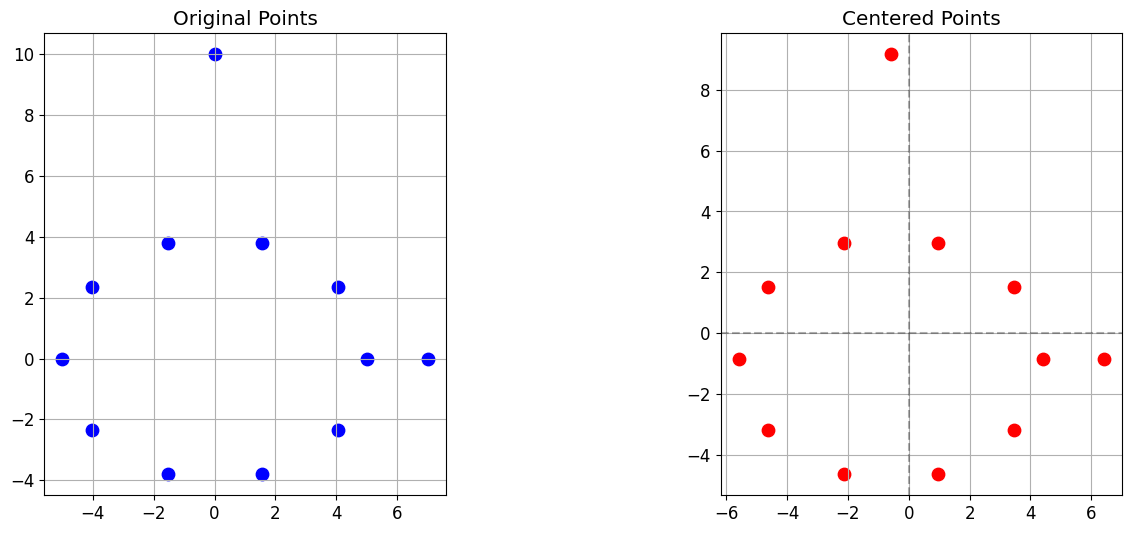

### Step 2: Create the design matrix

**Design Matrix B (first 5 rows):**

,0,1,2,3,4,5
0,-0.5833,9.1667,1.0000,0.3403,-7.5621,84.0278
1,6.4167,-0.8333,1.0000,41.1736,-7.5621,0.6944
2,4.4167,-0.8333,1.0000,19.5069,-5.2051,0.6944
3,3.4618,1.5178,1.0000,11.9838,7.4305,2.3036
4,0.9618,2.9709,1.0000,0.9250,4.0408,8.8260


### Step 3: QR Decomposition

**R Matrix:**

...

**Semi-minor axis b:** 4.590407

**Rotation angle α (radians):** 3.141593

**Rotation angle α (degrees):** 180.000000

**Final center z in original coordinates:**

,0,1
0,0.552173,1.338152


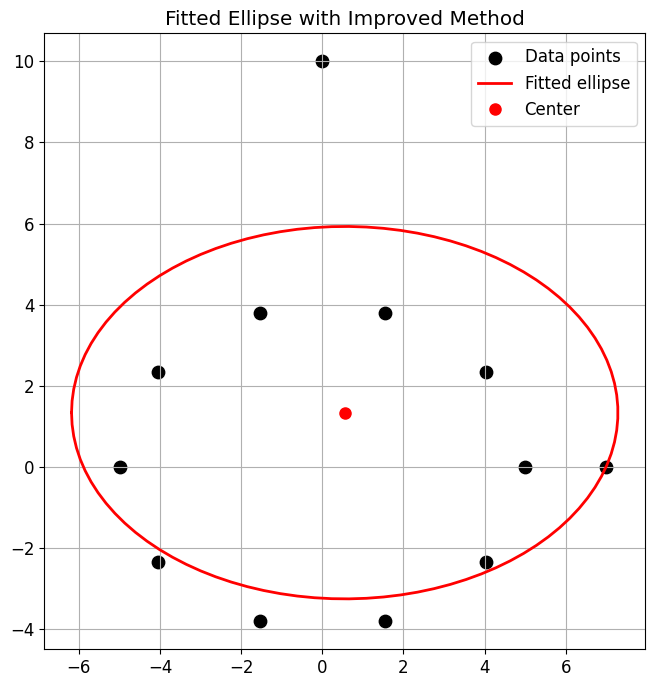

In [46]:
# Apply both fitting methods to original points
# params_bookstein, a11_b, a12_b, a22_b, b1_b, b2_b, c_b = bookstein_constraint_fitting(points)
# center_b, axes_b, angle_b = algebraic_to_geometric(a11_b, a12_b, a22_b, b1_b, b2_b, c_b)

# params_trace, a11_t, a12_t, a22_t, b1_t, b2_t, c_t = trace_constraint_fitting(points)
# center_t, axes_t, angle_t = algebraic_to_geometric(a11_t, a12_t, a22_t, b1_t, b2_t, c_t)

# Apply both improved fitting methods to original points
center_b_improved, axes_b_improved, angle_b_improved = fit_ellipse_bookstein_improved(points)
center_t_improved, axes_t_improved, angle_t_improved = fit_ellipse_trace_improved(points)

## Transformation 1: Shift by (-6, -6)

**Shift vector:**

,0,1
0,-6.00,-6.00


**Shifted points:**

,x,y
Point 1,1.0000,-6.0000
Point 2,-1.0000,-6.0000
Point 3,-1.9549,-3.6489
Point 4,-4.4549,-2.1958
Point 5,-7.5451,-2.1958
Point 6,-10.0451,-3.6489
Point 7,-11.0000,-6.0000
Point 8,-10.0451,-8.3511
Point 9,-7.5451,-9.8042
Point 10,-4.4549,-9.8042


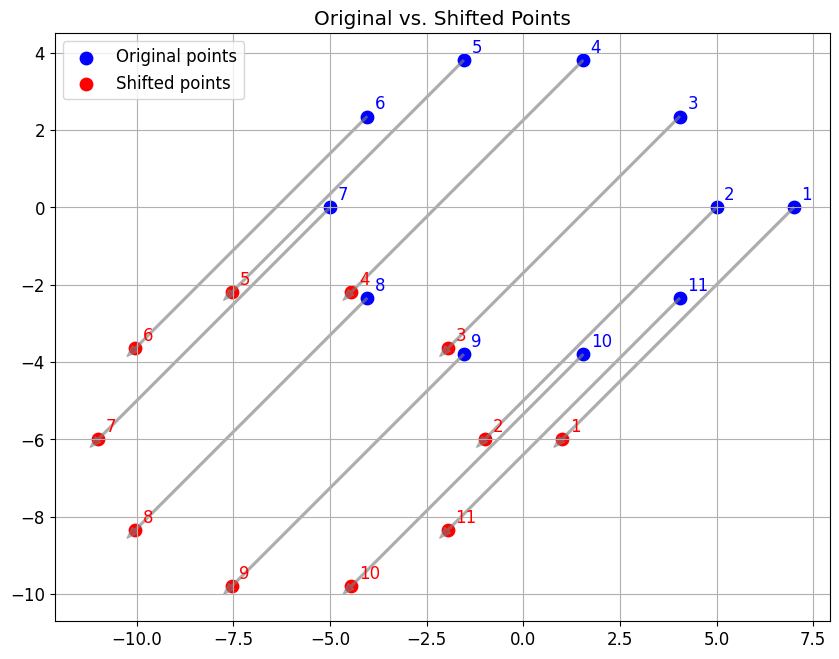

In [28]:
# Create transformation 1: shift by (-6, -6)
def apply_transformation1(points):
    display_step("Transformation 1: Shift by (-6, -6)")
    
    shift1 = np.array([-6, -6])
    points_shifted = points + shift1
    
    display_matrix(shift1, "Shift vector", 2)
    display_points(points_shifted, "Shifted points")
    
    # Visualize original and shifted points
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(points[:, 0], points[:, 1], color='blue', s=80, label='Original points')
    ax.scatter(points_shifted[:, 0], points_shifted[:, 1], color='red', s=80, label='Shifted points')
    
    for i, (p_orig, p_shift) in enumerate(zip(points, points_shifted)):
        ax.annotate(f"{i+1}", (p_orig[0]+0.2, p_orig[1]+0.2), fontsize=12, color='blue')
        ax.annotate(f"{i+1}", (p_shift[0]+0.2, p_shift[1]+0.2), fontsize=12, color='red')
        ax.arrow(p_orig[0], p_orig[1], shift1[0], shift1[1], color='gray', 
                 alpha=0.5, width=0.05, head_width=0.2)
    
    ax.grid(True)
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title('Original vs. Shifted Points')
    plt.show()
    
    return points_shifted

points_shifted1 = apply_transformation1(points)

## Improved Bookstein Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,-5.3636,-6.0000


**Original points:**

,x,y
Point 1,1.0000,-6.0000
Point 2,-1.0000,-6.0000
Point 3,-1.9549,-3.6489
Point 4,-4.4549,-2.1958
Point 5,-7.5451,-2.1958
Point 6,-10.0451,-3.6489
Point 7,-11.0000,-6.0000
Point 8,-10.0451,-8.3511
Point 9,-7.5451,-9.8042
Point 10,-4.4549,-9.8042


**Centered points:**

,x,y
Point 1,6.3636,0.0000
Point 2,4.3636,0.0000
Point 3,3.4087,2.3511
Point 4,0.9087,3.8042
Point 5,-2.1815,3.8042
Point 6,-4.6815,2.3511
Point 7,-5.6364,0.0000
Point 8,-4.6815,-2.3511
Point 9,-2.1815,-3.8042
Point 10,0.9087,-3.8042


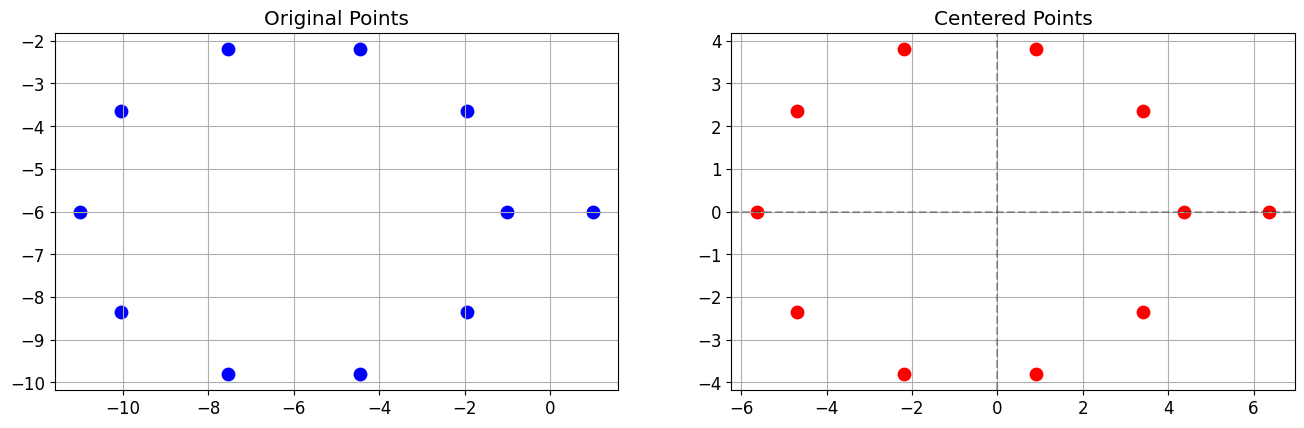

### Step 2: Create the design matrix

**Design Matrix B (first 5 rows):**

,0,1,2,3,4,5
0,6.3636,0.0000,1.0000,40.4959,0.0000,0.0000
1,4.3636,0.0000,1.0000,19.0413,0.0000,0.0000
2,3.4087,2.3511,1.0000,11.6195,11.3339,5.5277
3,0.9087,3.8042,1.0000,0.8258,4.8890,14.4719
4,-2.1815,3.8042,1.0000,4.7588,-11.7362,14.4719


### Step 3: QR Decomposition

**R Matrix:**

...

**Semi-minor axis b:** 3.736956

**Rotation angle α (radians):** 0.000000

**Rotation angle α (degrees):** 0.000000

**Final center z in original coordinates:**

,0,1
0,-5.662799,-6.000000


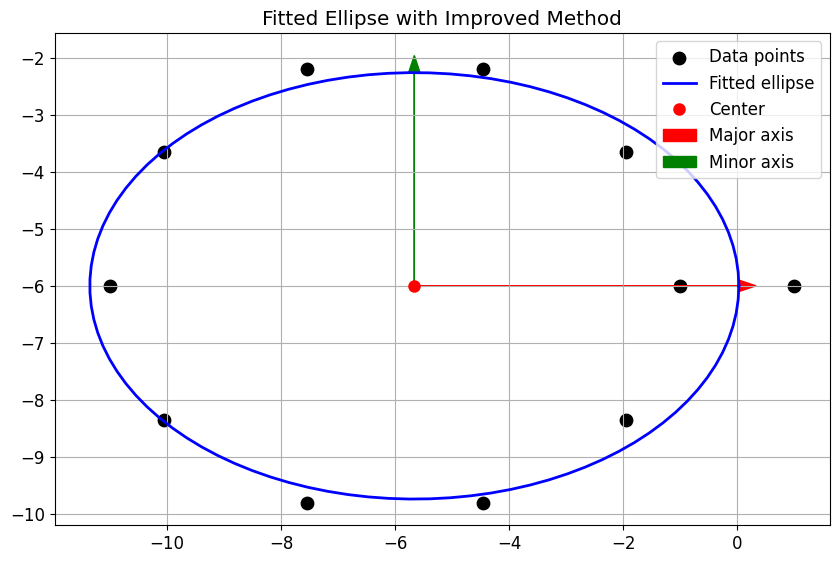

## Improved Trace Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,-5.3636,-6.0000


### Step 2: Create design matrix for trace constraint

...

**Semi-minor axis b:** 3.410737

**Rotation angle α (radians):** 0.000000

**Rotation angle α (degrees):** 0.000000

**Final center z in original coordinates:**

,0,1
0,-5.938597,-6.000000


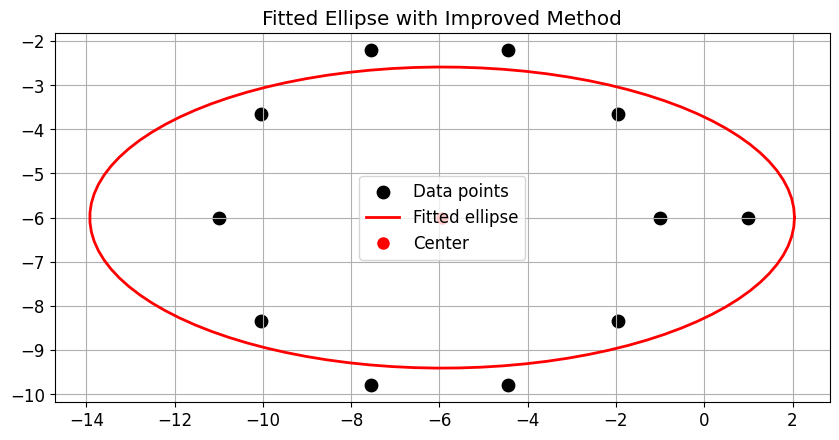

In [37]:
# Apply both fitting methods to shifted points
# params_bookstein_s1, a11_bs1, a12_bs1, a22_bs1, b1_bs1, b2_bs1, c_bs1 = bookstein_constraint_fitting(points_shifted1)
# center_bs1, axes_bs1, angle_bs1 = algebraic_to_geometric(a11_bs1, a12_bs1, a22_bs1, b1_bs1, b2_bs1, c_bs1)

# params_trace_s1, a11_ts1, a12_ts1, a22_ts1, b1_ts1, b2_ts1, c_ts1 = trace_constraint_fitting(points_shifted1)
# center_ts1, axes_ts1, angle_ts1 = algebraic_to_geometric(a11_ts1, a12_ts1, a22_ts1, b1_ts1, b2_ts1, c_ts1)

center_b_improved, axes_b_improved, angle_b_improved = fit_ellipse_bookstein_improved(points_shifted1)
center_t_improved, axes_t_improved, angle_t_improved = fit_ellipse_trace_improved(points_shifted1)

## Transformation 2: Shift by (-4, 4) and Rotate by π/4

**Shift vector:**

,0,1
0,-4.00,4.00


**Rotation matrix:**

,0,1
0,0.707107,-0.707107
1,0.707107,0.707107


**Points after shift:**

,x,y
Point 1,5.0000,-10.0000
Point 2,3.0000,-10.0000
Point 3,2.0451,-7.6489
Point 4,-0.4549,-6.1958
Point 5,-3.5451,-6.1958
Point 6,-6.0451,-7.6489
Point 7,-7.0000,-10.0000
Point 8,-6.0451,-12.3511
Point 9,-3.5451,-13.8042
Point 10,-0.4549,-13.8042


**Points after rotation (final):**

,x,y
Point 1,-3.5355,-10.6066
Point 2,-4.9497,-9.1924
Point 3,-3.9625,-6.8547
Point 4,-4.7028,-4.0594
Point 5,-6.8879,-1.8743
Point 6,-9.6831,-1.1341
Point 7,-12.0208,-2.1213
Point 8,-13.0081,-4.4590
Point 9,-12.2678,-7.2543
Point 10,-10.0827,-9.4394


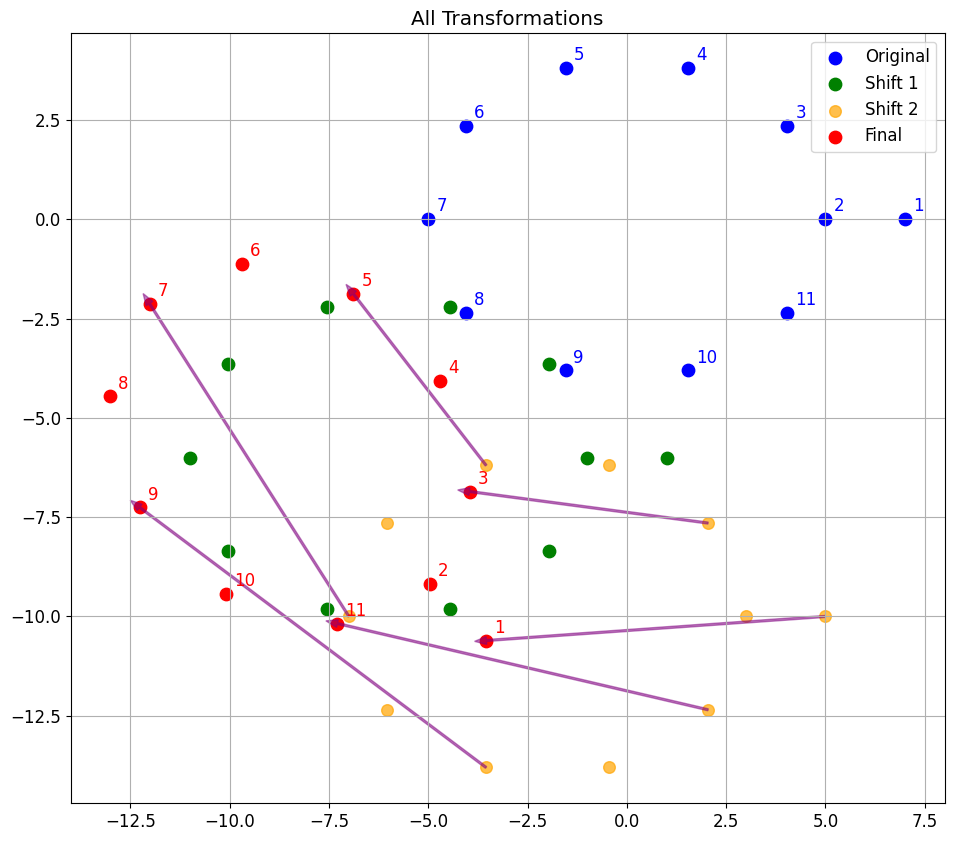

In [31]:
# Create transformation 2: shift by (-4, 4) and rotate by π/4
def apply_transformation2(points_shifted1):
    display_step("Transformation 2: Shift by (-4, 4) and Rotate by π/4")
    
    shift2 = np.array([-4, 4])
    theta = np.pi/4
    
    rotation = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    
    display_matrix(shift2, "Shift vector", 2)
    display_matrix(rotation, "Rotation matrix", 6)
    
    # First shift, then rotate
    points_centered = points_shifted1 - shift2
    points_transformed = np.dot(points_centered, rotation)
    
    display_points(points_centered, "Points after shift")
    display_points(points_transformed, "Points after rotation (final)")
    
    # Visualize all transformations
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot original points
    ax.scatter(points[:, 0], points[:, 1], color='blue', s=80, label='Original')
    
    # Plot first transformation (shift1)
    ax.scatter(points_shifted1[:, 0], points_shifted1[:, 1], color='green', s=80, label='Shift 1')
    
    # Plot intermediate step (after shift2, before rotation)
    ax.scatter(points_centered[:, 0], points_centered[:, 1], color='orange', s=70, alpha=0.7, label='Shift 2')
    
    # Plot final transformation (after rotation)
    ax.scatter(points_transformed[:, 0], points_transformed[:, 1], color='red', s=80, label='Final')
    
    # Add labels to points
    for i, p in enumerate(points):
        ax.annotate(f"{i+1}", (p[0]+0.2, p[1]+0.2), fontsize=12, color='blue')
    
    for i, p in enumerate(points_transformed):
        ax.annotate(f"{i+1}", (p[0]+0.2, p[1]+0.2), fontsize=12, color='red')
    
    # Add arrows showing the rotation for a few points
    for i in range(0, len(points_centered), 2):  # Show every other point
        p_centered = points_centered[i]
        p_rotated = points_transformed[i]
        ax.arrow(p_centered[0], p_centered[1], 
                 p_rotated[0]-p_centered[0], p_rotated[1]-p_centered[1], 
                 color='purple', alpha=0.5, width=0.05, head_width=0.2)
    
    ax.grid(True)
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title('All Transformations')
    plt.show()
    
    return points_transformed

points_shifted2 = apply_transformation2(points_shifted1)

## Improved Bookstein Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,-8.0353,-6.1068


**Original points:**

,x,y
Point 1,-3.5355,-10.6066
Point 2,-4.9497,-9.1924
Point 3,-3.9625,-6.8547
Point 4,-4.7028,-4.0594
Point 5,-6.8879,-1.8743
Point 6,-9.6831,-1.1341
Point 7,-12.0208,-2.1213
Point 8,-13.0081,-4.4590
Point 9,-12.2678,-7.2543
Point 10,-10.0827,-9.4394


**Centered points:**

,x,y
Point 1,4.4998,-4.4998
Point 2,3.0856,-3.0856
Point 3,4.0728,-0.7479
Point 4,3.3325,2.0474
Point 5,1.1474,4.2325
Point 6,-1.6478,4.9728
Point 7,-3.9855,3.9855
Point 8,-4.9728,1.6478
Point 9,-4.2325,-1.1474
Point 10,-2.0474,-3.3325


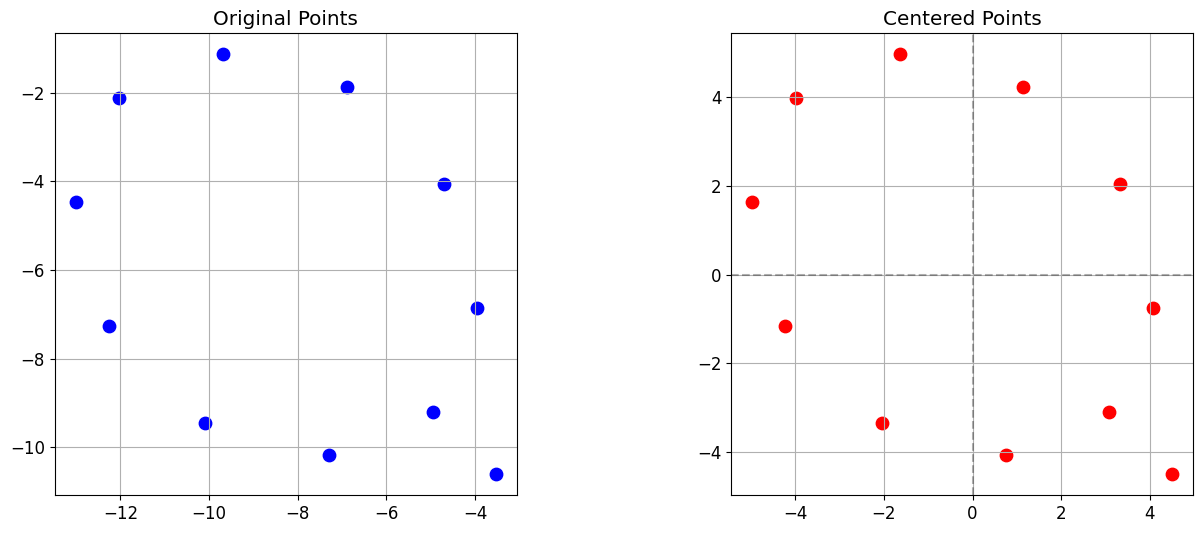

### Step 2: Create the design matrix

**Design Matrix B (first 5 rows):**

,0,1,2,3,4,5
0,4.4998,-4.4998,1.0000,20.2479,-28.6349,20.2479
1,3.0856,-3.0856,1.0000,9.5207,-13.4642,9.5207
2,4.0728,-0.7479,1.0000,16.5879,-4.3076,0.5593
3,3.3325,2.0474,1.0000,11.1059,9.6493,4.1919
4,1.1474,4.2325,1.0000,1.3166,6.8682,17.9141


### Step 3: QR Decomposition

**R Matrix:**

...

**Final center z in original coordinates:**

,0,1
0,-8.246844,-5.895292


**Note:** Swapping axes to ensure a (major axis) ≥ b (minor axis)

**Updated rotation angle α (radians):** -0.785398

**Updated rotation angle α (degrees):** -45.000000

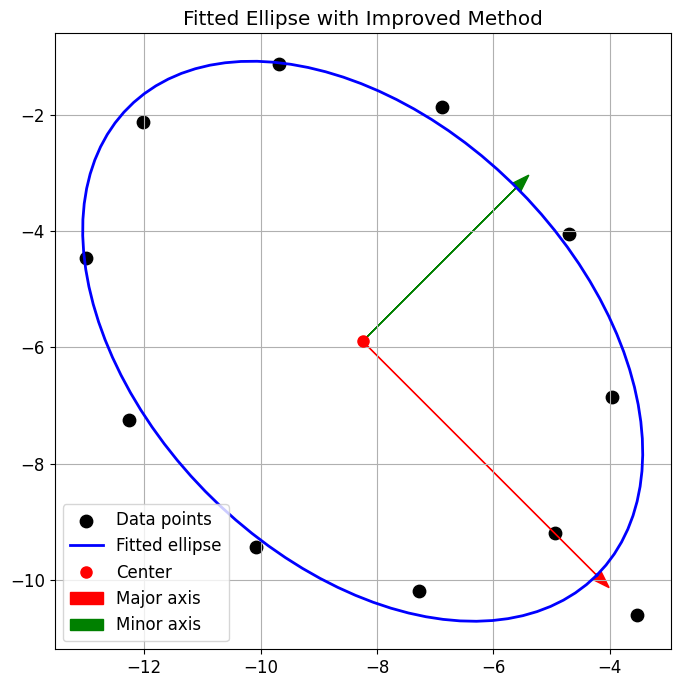

## Improved Trace Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,-8.0353,-6.1068


### Step 2: Create design matrix for trace constraint

...

**Semi-minor axis b:** 3.575229

**Rotation angle α (radians):** 2.958940

**Rotation angle α (degrees):** 169.534797

**Final center z in original coordinates:**

,0,1
0,-8.332884,-5.985205


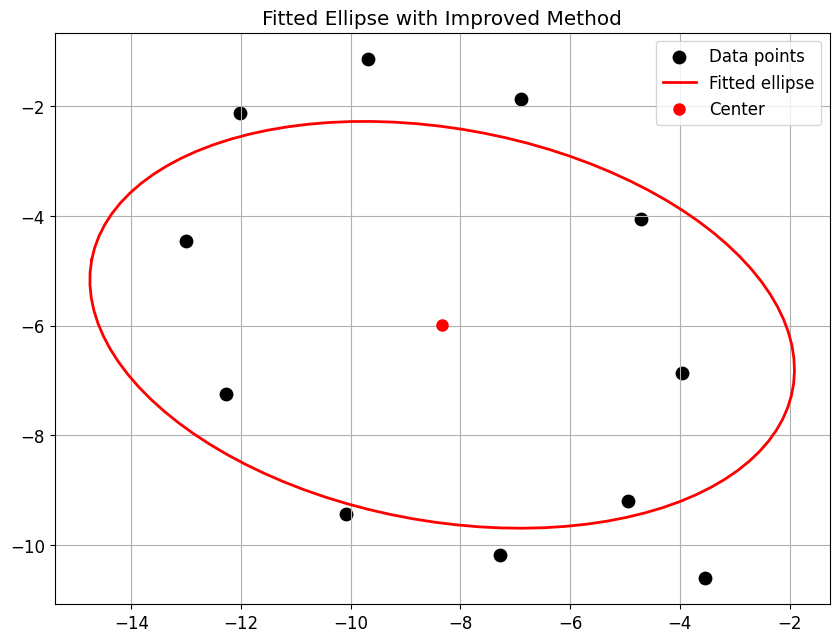

In [34]:
center_b_improved, axes_b_improved, angle_b_improved = fit_ellipse_bookstein_improved(points_shifted2)
center_t_improved, axes_t_improved, angle_t_improved = fit_ellipse_trace_improved(points_shifted2)

In [39]:
# Implementation of geometric ellipse fitting in parametric form
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math

In [38]:
def geometric_ellipse_fit_parametric(points):
    """
    Fit an ellipse to points using geometric distance minimization in parametric form.
    
    This implements the method described in section 6 of the paper by Gander, Golub, and Strebel.
    """
    display_step("Geometric Ellipse Fitting in Parametric Form")
    
    # Extract x and y coordinates
    x_data = points[:, 0]
    y_data = points[:, 1]
    data = np.vstack([x_data, y_data])
    m = len(x_data)
    
    display_points(points, "Input points")
    
    # First, get initial guess using algebraic fit
    display_substep("Step 1: Get initial parameters using algebraic fit")
    
    # Initialize parameters using center of gravity and circle fit
    x_mean = np.mean(x_data)
    y_mean = np.mean(y_data)
    r = np.mean(np.sqrt((x_data - x_mean)**2 + (y_data - y_mean)**2))
    
    # Initial guess: z = center, a slightly larger than b, α = 0
    z_init = np.array([x_mean, y_mean])
    a_init = r
    b_init = r * 0.8  # Avoid a=b which would make Jacobian singular
    alpha_init = 0.0
    
    display_parameter("Initial center x₀", z_init[0])
    display_parameter("Initial center y₀", z_init[1])
    display_parameter("Initial semi-major axis a", a_init)
    display_parameter("Initial semi-minor axis b", b_init)
    display_parameter("Initial rotation angle α", alpha_init)
    
    # Initial guess for angle parameters φᵢ - project points onto circle
    phi_init = np.arctan2(y_data - z_init[1], x_data - z_init[0])
    
    # Combine all parameters into a single vector
    params_init = np.concatenate([[alpha_init, a_init, b_init], z_init, phi_init])
    
    display_matrix(phi_init, "Initial φ values (first few)", 4)
    
    # Define the residual function
    def residual_function(params):
        """Calculate residuals for the ellipse fitting problem"""
        alpha, a, b, z1, z2 = params[0:5]
        phi = params[5:]
        
        # Rotation matrix Q(α)
        Q = np.array([
            [np.cos(alpha), -np.sin(alpha)],
            [np.sin(alpha), np.cos(alpha)]
        ])
        
        # Center vector
        z = np.array([z1, z2])
        
        # Calculate the residuals for each point
        residuals = np.zeros(2 * m)
        
        for i in range(m):
            # Calculate ellipse point
            ellipse_point = z + Q @ np.array([a * np.cos(phi[i]), b * np.sin(phi[i])])
            
            # Calculate residual (difference between data point and ellipse point)
            residuals[2*i:2*i+2] = np.array([x_data[i], y_data[i]]) - ellipse_point
            
        return residuals
    
    # Define the Jacobian function
    def jacobian_function(params):
        """Calculate the Jacobian matrix for the ellipse fitting problem"""
        alpha, a, b, z1, z2 = params[0:5]
        phi = params[5:]
        
        # Rotation matrix Q(α)
        Q = np.array([
            [np.cos(alpha), -np.sin(alpha)],
            [np.sin(alpha), np.cos(alpha)]
        ])
        
        # Derivative of Q with respect to α
        dQ = np.array([
            [-np.sin(alpha), -np.cos(alpha)],
            [np.cos(alpha), -np.sin(alpha)]
        ])
        
        # Initialize Jacobian matrix
        J = np.zeros((2 * m, 5 + m))
        
        for i in range(m):
            # Partial derivatives with respect to φᵢ
            # Only the i-th point depends on φᵢ
            J[2*i:2*i+2, 5+i] = -Q @ np.array([
                [-a * np.sin(phi[i])], 
                [b * np.cos(phi[i])]
            ]).flatten()
            
            # Partial derivative with respect to α
            J[2*i:2*i+2, 0] = -dQ @ np.array([
                [a * np.cos(phi[i])], 
                [b * np.sin(phi[i])]
            ]).flatten()
            
            # Partial derivative with respect to a
            J[2*i:2*i+2, 1] = -Q @ np.array([
                [np.cos(phi[i])], 
                [0]
            ]).flatten()
            
            # Partial derivative with respect to b
            J[2*i:2*i+2, 2] = -Q @ np.array([
                [0], 
                [np.sin(phi[i])]
            ]).flatten()
            
            # Partial derivatives with respect to z₁, z₂
            J[2*i, 3] = -1  # ∂/∂z₁
            J[2*i+1, 4] = -1  # ∂/∂z₂
            
        return J
    
    display_substep("Step 2: Solve nonlinear least squares problem")
    display(Markdown("""
    The nonlinear least squares problem is:
    
    Find parameters that minimize:
    
    $$\sum_{i=1}^{m} \left\| \mathbf{x}_i - \mathbf{z} - \mathbf{Q}(\alpha) \begin{bmatrix} a\cos\phi_i \\ b\sin\phi_i \end{bmatrix} \right\|^2$$
    
    where:
    - $\mathbf{x}_i = (x_i, y_i)$ are the data points
    - $\mathbf{z} = (z_1, z_2)$ is the ellipse center
    - $\mathbf{Q}(\alpha)$ is the rotation matrix
    - $a, b$ are the semi-axes
    - $\phi_i$ are the angle parameters for each point
    """))
    
    # Use Levenberg-Marquardt algorithm to solve the nonlinear least squares problem
    result = least_squares(
        residual_function, 
        params_init, 
        jac=jacobian_function, 
        method='lm',
        ftol=1e-10, 
        xtol=1e-10, 
        gtol=1e-10,
        max_nfev=1000
    )
    
    # Extract the optimized parameters
    params_opt = result.x
    alpha_opt, a_opt, b_opt, z1_opt, z2_opt = params_opt[0:5]
    phi_opt = params_opt[5:]
    
    # Ensure a ≥ b (if not, swap and adjust angle)
    if a_opt < b_opt:
        a_opt, b_opt = b_opt, a_opt
        alpha_opt = alpha_opt + np.pi/2
        display(Markdown("**Note:** Swapping axes to ensure a ≥ b"))
    
    display_substep("Step 3: Results of optimization")
    
    display_parameter("Final center x₀", z1_opt)
    display_parameter("Final center y₀", z2_opt)
    display_parameter("Final semi-major axis a", a_opt)
    display_parameter("Final semi-minor axis b", b_opt)
    display_parameter("Final rotation angle α (radians)", alpha_opt)
    display_parameter("Final rotation angle α (degrees)", alpha_opt * 180 / np.pi)
    display_parameter("Axis ratio (a/b)", a_opt / b_opt)
    display_parameter("Optimization status", result.status)
    display_parameter("Final cost (sum of squared residuals)", result.cost)
    display_parameter("Number of function evaluations", result.nfev)
    display_parameter("Number of Jacobian evaluations", result.njev)
    
    display_substep("Step 4: Calculating distances to the ellipse")
    
    # Calculate the fitted points on the ellipse for each optimal φᵢ
    Q_opt = np.array([
        [np.cos(alpha_opt), -np.sin(alpha_opt)],
        [np.sin(alpha_opt), np.cos(alpha_opt)]
    ])
    
    z_opt = np.array([z1_opt, z2_opt])
    
    ellipse_points = np.zeros((m, 2))
    distances = np.zeros(m)
    
    for i in range(m):
        ellipse_point = z_opt + Q_opt @ np.array([a_opt * np.cos(phi_opt[i]), b_opt * np.sin(phi_opt[i])])
        ellipse_points[i] = ellipse_point
        distances[i] = np.linalg.norm(np.array([x_data[i], y_data[i]]) - ellipse_point)
    
    mean_distance = np.mean(distances)
    max_distance = np.max(distances)
    
    display_parameter("Mean distance from points to ellipse", mean_distance)
    display_parameter("Maximum distance from points to ellipse", max_distance)
    
    # Create a DataFrame to show the distances
    distance_data = np.column_stack([x_data, y_data, distances])
    df_distances = pd.DataFrame(distance_data, columns=['x', 'y', 'distance'])
    df_distances.index = [f"Point {i+1}" for i in range(m)]
    display(Markdown("**Distances from points to the fitted ellipse:**"))
    display(df_distances.style.format({'x': '{:.4f}', 'y': '{:.4f}', 'distance': '{:.4f}'}))
    
    # Visualize the fitted ellipse
    display_substep("Step 5: Visualization of the fitted ellipse")
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot data points
    ax.scatter(x_data, y_data, c='black', s=80, label='Data points')
    
    # Plot the corresponding points on the ellipse
    for i in range(m):
        ax.plot([x_data[i], ellipse_points[i, 0]], [y_data[i], ellipse_points[i, 1]], 
                'r-', alpha=0.5, linewidth=1)
    
    # Plot the fitted ellipse
    t = np.linspace(0, 2*np.pi, 200)
    ellipse_points_curve = np.array([
        z_opt[0] + a_opt * np.cos(t) * np.cos(alpha_opt) - b_opt * np.sin(t) * np.sin(alpha_opt),
        z_opt[1] + a_opt * np.cos(t) * np.sin(alpha_opt) + b_opt * np.sin(t) * np.cos(alpha_opt)
    ]).T
    
    ax.plot(ellipse_points_curve[:, 0], ellipse_points_curve[:, 1], 'b-', 
            linewidth=2.5, label=f'Geometric fit (cost={result.cost:.4f})')
    
    # Plot the ellipse center
    ax.plot(z_opt[0], z_opt[1], 'bo', markersize=10, label='Ellipse center')
    
    # Plot the ellipse axes
    # Major axis
    ax.arrow(z_opt[0], z_opt[1], 
             a_opt * np.cos(alpha_opt), a_opt * np.sin(alpha_opt), 
             head_width=0.3, head_length=0.5, fc='blue', ec='blue', label='Major axis')
    
    # Minor axis
    ax.arrow(z_opt[0], z_opt[1], 
             -b_opt * np.sin(alpha_opt), b_opt * np.cos(alpha_opt), 
             head_width=0.3, head_length=0.5, fc='green', ec='green', label='Minor axis')
    
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    ax.set_title('Geometric Ellipse Fit in Parametric Form')
    
    plt.tight_layout()
    plt.show()
    
    # Return the fitted parameters
    return z_opt, (a_opt, b_opt), alpha_opt, result.cost

In [50]:
# # Fixed comparison function with error handling
# def compare_ellipse_fits(points):
#     """
#     Compare algebraic (Bookstein and Trace constraints) and geometric fits
#     with proper error handling.
#     """
#     display_step("Comparison of All Ellipse Fitting Methods")
    
#     # Fit ellipses using all methods with error handling
#     results_data = []
#     methods = []
    
#     # Bookstein method
#     start_time = time.time()
#     try:
#         z_bookstein, axes_bookstein, angle_bookstein = fit_ellipse_bookstein_improved(points)
#         time_bookstein = time.time() - start_time
        
#         if z_bookstein is not None:  # Check if the fit was successful
#             results_data.append({
#                 'Method': 'Bookstein',
#                 'Center_x': z_bookstein[0],
#                 'Center_y': z_bookstein[1],
#                 'Semi-major axis': axes_bookstein[0],
#                 'Semi-minor axis': axes_bookstein[1],
#                 'Angle (degrees)': angle_bookstein * 180 / np.pi,
#                 'Axis ratio (a/b)': axes_bookstein[0] / axes_bookstein[1],
#                 'Computation time (s)': time_bookstein,
#                 'Status': 'Success'
#             })
#             methods.append(('Bookstein', z_bookstein, axes_bookstein, angle_bookstein))
#         else:
#             results_data.append({
#                 'Method': 'Bookstein',
#                 'Status': 'Failed - No valid ellipse found',
#                 'Computation time (s)': time_bookstein
#             })
#     except Exception as e:
#         results_data.append({
#             'Method': 'Bookstein',
#             'Status': f'Failed - {str(e)}',
#             'Computation time (s)': time.time() - start_time
#         })
    
#     # Trace method
#     start_time = time.time()
#     try:
#         z_trace, axes_trace, angle_trace = fit_ellipse_trace_improved(points)
#         time_trace = time.time() - start_time
        
#         if z_trace is not None:  # Check if the fit was successful
#             results_data.append({
#                 'Method': 'Trace',
#                 'Center_x': z_trace[0],
#                 'Center_y': z_trace[1],
#                 'Semi-major axis': axes_trace[0],
#                 'Semi-minor axis': axes_trace[1],
#                 'Angle (degrees)': angle_trace * 180 / np.pi,
#                 'Axis ratio (a/b)': axes_trace[0] / axes_trace[1],
#                 'Computation time (s)': time_trace,
#                 'Status': 'Success'
#             })
#             methods.append(('Trace', z_trace, axes_trace, angle_trace))
#         else:
#             results_data.append({
#                 'Method': 'Trace',
#                 'Status': 'Failed - No valid ellipse found',
#                 'Computation time (s)': time_trace
#             })
#     except Exception as e:
#         results_data.append({
#             'Method': 'Trace',
#             'Status': f'Failed - {str(e)}',
#             'Computation time (s)': time.time() - start_time
#         })
    
#     # Geometric method
#     start_time = time.time()
#     try:
#         z_geometric, axes_geometric, angle_geometric, cost_geometric = geometric_ellipse_fit_parametric(points)
#         time_geometric = time.time() - start_time
        
#         if z_geometric is not None:  # Check if the fit was successful
#             results_data.append({
#                 'Method': 'Geometric',
#                 'Center_x': z_geometric[0],
#                 'Center_y': z_geometric[1],
#                 'Semi-major axis': axes_geometric[0],
#                 'Semi-minor axis': axes_geometric[1],
#                 'Angle (degrees)': angle_geometric * 180 / np.pi,
#                 'Axis ratio (a/b)': axes_geometric[0] / axes_geometric[1],
#                 'Computation time (s)': time_geometric,
#                 'Cost': cost_geometric,
#                 'Status': 'Success'
#             })
#             methods.append(('Geometric', z_geometric, axes_geometric, angle_geometric))
#         else:
#             results_data.append({
#                 'Method': 'Geometric',
#                 'Status': 'Failed - No valid ellipse found',
#                 'Computation time (s)': time_geometric
#             })
#     except Exception as e:
#         results_data.append({
#             'Method': 'Geometric',
#             'Status': f'Failed - {str(e)}',
#             'Computation time (s)': time.time() - start_time
#         })
    
#     # Create DataFrame with results
#     df_results = pd.DataFrame(results_data)
#     display(Markdown("**Comparison of Ellipse Fitting Methods:**"))
#     display(df_results)
    
#     # Visualize successful fits
#     if methods:  # Only plot if we have at least one successful fit
#         fig, ax = plt.subplots(figsize=(12, 10))
        
#         # Plot data points
#         ax.scatter(points[:, 0], points[:, 1], c='black', s=80, label='Data points')
        
#         # Plot ellipses for successful methods
#         t = np.linspace(0, 2*np.pi, 200)
#         colors = {'Bookstein': 'blue', 'Trace': 'red', 'Geometric': 'green'}
        
#         for method_name, z, axes, angle in methods:
#             color = colors[method_name]
            
#             # Generate ellipse points
#             ellipse_curve = np.array([
#                 z[0] + axes[0] * np.cos(t) * np.cos(angle) - 
#                         axes[1] * np.sin(t) * np.sin(angle),
#                 z[1] + axes[0] * np.cos(t) * np.sin(angle) + 
#                         axes[1] * np.sin(t) * np.cos(angle)
#             ]).T
            
#             # Plot ellipse
#             ax.plot(ellipse_curve[:, 0], ellipse_curve[:, 1], 
#                     color=color, linewidth=2, label=f'{method_name} constraint')
            
#             # Plot center
#             ax.plot(z[0], z[1], f'{color}o', markersize=8)
        
#         ax.set_aspect('equal')
#         ax.grid(True)
#         ax.legend()
#         ax.set_title('Comparison of Ellipse Fitting Methods')
        
#         plt.tight_layout()
#         plt.show()
#     else:
#         display(Markdown("**No successful ellipse fits to visualize.**"))
    
#     return df_results

In [63]:
# Function to compare algebraic and geometric fits
def compare_ellipse_fits(points):
    """
    Compare algebraic (Bookstein and Trace constraints) and geometric fits.
    """
    display_step("Comparison of All Ellipse Fitting Methods")
    
    # Fit ellipses using all methods
    start_time = time.time()
    z_bookstein, axes_bookstein, angle_bookstein = fit_ellipse_bookstein_improved(points)
    time_bookstein = time.time() - start_time
    
    start_time = time.time()
    z_trace, axes_trace, angle_trace = fit_ellipse_trace_improved(points)
    time_trace = time.time() - start_time
    
    start_time = time.time()
    z_geometric, axes_geometric, angle_geometric, cost_geometric = geometric_ellipse_fit_parametric(points)
    time_geometric = time.time() - start_time
    
    # Create a DataFrame to compare results
    results = {
        'Method': ['Bookstein', 'Trace', 'Geometric'],
        'Center_x': [z_bookstein[0], z_trace[0], z_geometric[0]],
        'Center_y': [z_bookstein[1], z_trace[1], z_geometric[1]],
        'Semi-major axis': [axes_bookstein[0], axes_trace[0], axes_geometric[0]],
        'Semi-minor axis': [axes_bookstein[1], axes_trace[1], axes_geometric[1]],
        'Angle (degrees)': [
            angle_bookstein * 180 / np.pi,
            angle_trace * 180 / np.pi,
            angle_geometric * 180 / np.pi
        ],
        'Axis ratio (a/b)': [
            axes_bookstein[0] / axes_bookstein[1],
            axes_trace[0] / axes_trace[1],
            axes_geometric[0] / axes_geometric[1]
        ],
        'Computation time (s)': [time_bookstein, time_trace, time_geometric]
    }
    
    df_results = pd.DataFrame(results)
    display(Markdown("**Comparison of Ellipse Fitting Methods:**"))
    display(df_results.style.format({
        'Center_x': '{:.4f}',
        'Center_y': '{:.4f}',
        'Semi-major axis': '{:.4f}',
        'Semi-minor axis': '{:.4f}',
        'Angle (degrees)': '{:.2f}',
        'Axis ratio (a/b)': '{:.4f}',
        'Computation time (s)': '{:.4f}'
    }))
    
    # Visualize all fitted ellipses
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot data points
    ax.scatter(points[:, 0], points[:, 1], c='black', s=80, label='Data points')
    
    # Plot all ellipses
    t = np.linspace(0, 2*np.pi, 200)
    
    # Bookstein ellipse
    ellipse_bookstein = np.array([
        z_bookstein[0] + axes_bookstein[0] * np.cos(t) * np.cos(angle_bookstein) - 
                        axes_bookstein[1] * np.sin(t) * np.sin(angle_bookstein),
        z_bookstein[1] + axes_bookstein[0] * np.cos(t) * np.sin(angle_bookstein) + 
                        axes_bookstein[1] * np.sin(t) * np.cos(angle_bookstein)
    ]).T
    ax.plot(ellipse_bookstein[:, 0], ellipse_bookstein[:, 1], 'b-', 
            linewidth=2, label='Bookstein constraint')
    
    # Trace ellipse
    ellipse_trace = np.array([
        z_trace[0] + axes_trace[0] * np.cos(t) * np.cos(angle_trace) - 
                    axes_trace[1] * np.sin(t) * np.sin(angle_trace),
        z_trace[1] + axes_trace[0] * np.cos(t) * np.sin(angle_trace) + 
                    axes_trace[1] * np.sin(t) * np.cos(angle_trace)
    ]).T
    ax.plot(ellipse_trace[:, 0], ellipse_trace[:, 1], 'r-', 
            linewidth=2, label='Trace constraint')
    
    # Geometric ellipse
    ellipse_geometric = np.array([
        z_geometric[0] + axes_geometric[0] * np.cos(t) * np.cos(angle_geometric) - 
                        axes_geometric[1] * np.sin(t) * np.sin(angle_geometric),
        z_geometric[1] + axes_geometric[0] * np.cos(t) * np.sin(angle_geometric) + 
                        axes_geometric[1] * np.sin(t) * np.cos(angle_geometric)
    ]).T
    ax.plot(ellipse_geometric[:, 0], ellipse_geometric[:, 1], 'g-', 
            linewidth=2, label='Geometric fit')
    
    # Plot centers with matching colors
    ax.plot(z_bookstein[0], z_bookstein[1], 'bo', markersize=8)
    ax.plot(z_trace[0], z_trace[1], 'ro', markersize=8)
    ax.plot(z_geometric[0], z_geometric[1], 'go', markersize=8)
    
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    ax.set_title('Comparison of Ellipse Fitting Methods')
    
    plt.tight_layout()
    plt.show()
    
    return df_results

In [60]:
# Updated comparison function with fixed plotting code
def compare_all_ellipse_fits(points):
    """
    Compare all ellipse fitting methods:
    1. Bookstein constraint (algebraic)
    2. Trace constraint (algebraic)
    3. Direct ellipse-specific (algebraic, guarantees ellipse)
    4. Geometric parametric (minimizes geometric distance)
    """
    display_step("Comparison of All Ellipse Fitting Methods")
    
    # Fit ellipses using all methods with error handling
    results_data = []
    methods = []
    
    # Bookstein method
    start_time = time.time()
    try:
        z_bookstein, axes_bookstein, angle_bookstein = fit_ellipse_bookstein_improved(points)
        time_bookstein = time.time() - start_time
        
        if z_bookstein is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Bookstein',
                'Center_x': z_bookstein[0],
                'Center_y': z_bookstein[1],
                'Semi-major axis': axes_bookstein[0],
                'Semi-minor axis': axes_bookstein[1],
                'Angle (degrees)': angle_bookstein * 180 / np.pi,
                'Axis ratio (a/b)': axes_bookstein[0] / axes_bookstein[1],
                'Computation time (s)': time_bookstein,
                'Status': 'Success'
            })
            methods.append(('Bookstein', z_bookstein, axes_bookstein, angle_bookstein, 'blue'))
        else:
            results_data.append({
                'Method': 'Bookstein',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_bookstein
            })
    except Exception as e:
        results_data.append({
            'Method': 'Bookstein',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Trace method
    start_time = time.time()
    try:
        z_trace, axes_trace, angle_trace = fit_ellipse_trace_improved(points)
        time_trace = time.time() - start_time
        
        if z_trace is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Trace',
                'Center_x': z_trace[0],
                'Center_y': z_trace[1],
                'Semi-major axis': axes_trace[0],
                'Semi-minor axis': axes_trace[1],
                'Angle (degrees)': angle_trace * 180 / np.pi,
                'Axis ratio (a/b)': axes_trace[0] / axes_trace[1],
                'Computation time (s)': time_trace,
                'Status': 'Success'
            })
            methods.append(('Trace', z_trace, axes_trace, angle_trace, 'red'))
        else:
            results_data.append({
                'Method': 'Trace',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_trace
            })
    except Exception as e:
        results_data.append({
            'Method': 'Trace',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Direct ellipse-specific method
    start_time = time.time()
    try:
        z_direct, axes_direct, angle_direct = fit_ellipse_direct(points)
        time_direct = time.time() - start_time
        
        if z_direct is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Direct',
                'Center_x': z_direct[0],
                'Center_y': z_direct[1],
                'Semi-major axis': axes_direct[0],
                'Semi-minor axis': axes_direct[1],
                'Angle (degrees)': angle_direct * 180 / np.pi,
                'Axis ratio (a/b)': axes_direct[0] / axes_direct[1],
                'Computation time (s)': time_direct,
                'Status': 'Success'
            })
            methods.append(('Direct', z_direct, axes_direct, angle_direct, 'purple'))
        else:
            results_data.append({
                'Method': 'Direct',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_direct
            })
    except Exception as e:
        results_data.append({
            'Method': 'Direct',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Geometric method
    start_time = time.time()
    try:
        z_geometric, axes_geometric, angle_geometric, cost_geometric = geometric_ellipse_fit_parametric(points)
        time_geometric = time.time() - start_time
        
        if z_geometric is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Geometric',
                'Center_x': z_geometric[0],
                'Center_y': z_geometric[1],
                'Semi-major axis': axes_geometric[0],
                'Semi-minor axis': axes_geometric[1],
                'Angle (degrees)': angle_geometric * 180 / np.pi,
                'Axis ratio (a/b)': axes_geometric[0] / axes_geometric[1],
                'Computation time (s)': time_geometric,
                'Cost': cost_geometric,
                'Status': 'Success'
            })
            methods.append(('Geometric', z_geometric, axes_geometric, angle_geometric, 'green'))
        else:
            results_data.append({
                'Method': 'Geometric',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_geometric
            })
    except Exception as e:
        results_data.append({
            'Method': 'Geometric',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Create DataFrame with results
    df_results = pd.DataFrame(results_data)
    display(Markdown("**Comparison of Ellipse Fitting Methods:**"))
    display(df_results)
    
    # Visualize successful fits
    if methods:  # Only plot if we have at least one successful fit
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Plot data points
        ax.scatter(points[:, 0], points[:, 1], c='black', s=80, label='Data points')
        
        # Plot ellipses for successful methods
        t = np.linspace(0, 2*np.pi, 200)
        
        for method_name, z, axes, angle, color in methods:
            # Generate ellipse points
            ellipse_curve = np.array([
                z[0] + axes[0] * np.cos(t) * np.cos(angle) - 
                        axes[1] * np.sin(t) * np.sin(angle),
                z[1] + axes[0] * np.cos(t) * np.sin(angle) + 
                        axes[1] * np.sin(t) * np.cos(angle)
            ]).T
            
            # Plot ellipse
            ax.plot(ellipse_curve[:, 0], ellipse_curve[:, 1], 
                    color=color, linewidth=2, label=f'{method_name} method')
            
            # Plot center - FIXED: Specify color separately instead of in format string
            ax.plot(z[0], z[1], 'o', color=color, markersize=8)
        
        ax.set_aspect('equal')
        ax.grid(True)
        ax.legend()
        ax.set_title('Comparison of Ellipse Fitting Methods')
        
        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("**No successful ellipse fits to visualize.**"))
    
    return df_results

## Comparison of All Ellipse Fitting Methods

## Improved Bookstein Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,0.5833,0.8333


**Original points:**

,x,y
Point 1,0.0000,10.0000
Point 2,7.0000,0.0000
Point 3,5.0000,0.0000
Point 4,4.0451,2.3511
Point 5,1.5451,3.8042
Point 6,-1.5451,3.8042
Point 7,-4.0451,2.3511
Point 8,-5.0000,0.0000
Point 9,-4.0451,-2.3511
Point 10,-1.5451,-3.8042


**Centered points:**

,x,y
Point 1,-0.5833,9.1667
Point 2,6.4167,-0.8333
Point 3,4.4167,-0.8333
Point 4,3.4618,1.5178
Point 5,0.9618,2.9709
Point 6,-2.1284,2.9709
Point 7,-4.6284,1.5178
Point 8,-5.5833,-0.8333
Point 9,-4.6284,-3.1844
Point 10,-2.1284,-4.6375


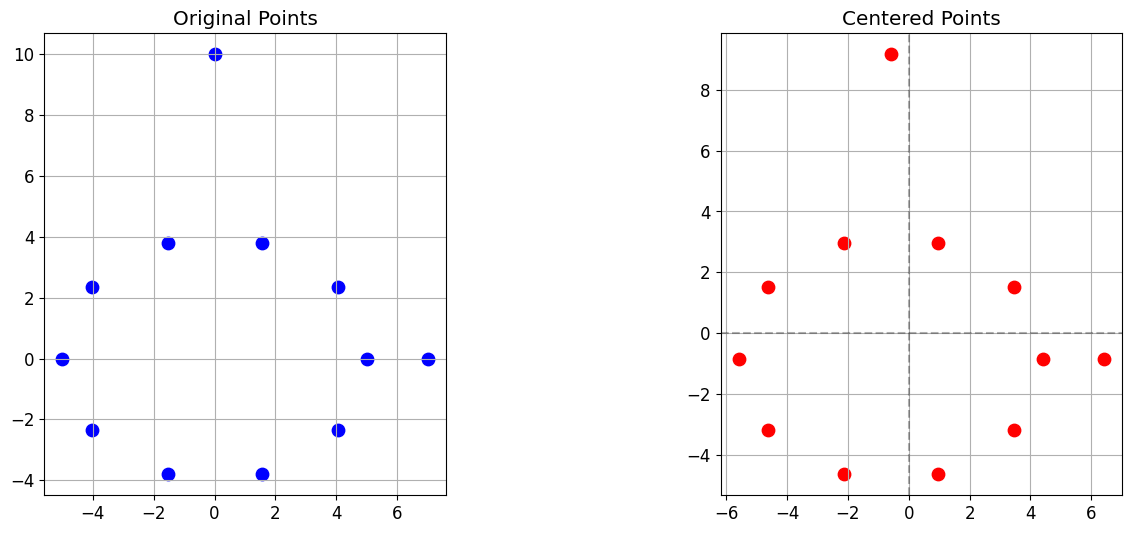

### Step 2: Create the design matrix

**Design Matrix B (first 5 rows):**

,0,1,2,3,4,5
0,-0.5833,9.1667,1.0000,0.3403,-7.5621,84.0278
1,6.4167,-0.8333,1.0000,41.1736,-7.5621,0.6944
2,4.4167,-0.8333,1.0000,19.5069,-5.2051,0.6944
3,3.4618,1.5178,1.0000,11.9838,7.4305,2.3036
4,0.9618,2.9709,1.0000,0.9250,4.0408,8.8260


### Step 3: QR Decomposition

**R Matrix:**

...

**Semi-minor axis b:** 0.000000

**Rotation angle α (radians):** -2.356194

**Rotation angle α (degrees):** -135.000000

**Final center z in original coordinates:**

,0,1
0,-0.000000,-0.000000


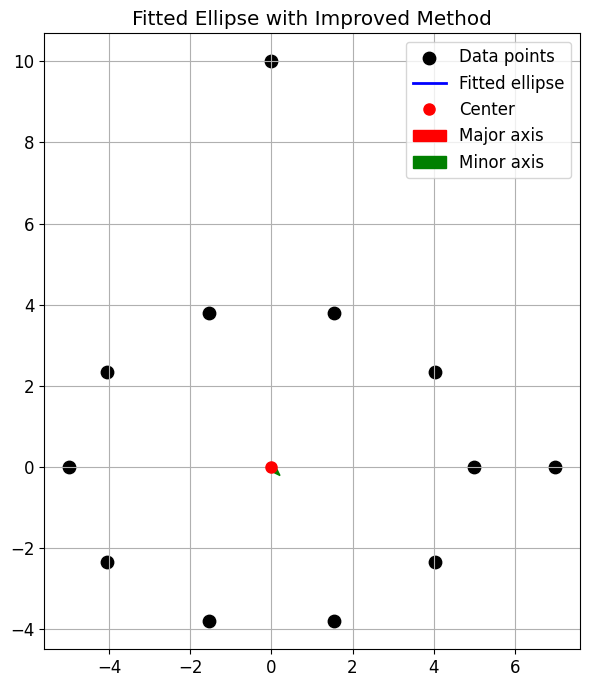

## Improved Trace Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,0.5833,0.8333


### Step 2: Create design matrix for trace constraint

...

**Semi-minor axis b:** 4.590407

**Rotation angle α (radians):** 3.141593

**Rotation angle α (degrees):** 180.000000

**Final center z in original coordinates:**

,0,1
0,0.552173,1.338152


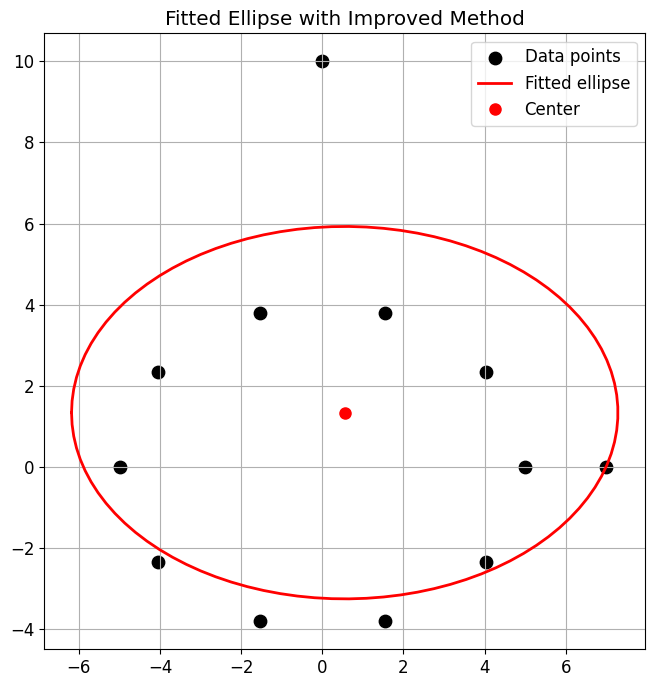

## Geometric Ellipse Fitting in Parametric Form

**Input points:**

,x,y
Point 1,0.0000,10.0000
Point 2,7.0000,0.0000
Point 3,5.0000,0.0000
Point 4,4.0451,2.3511
Point 5,1.5451,3.8042
Point 6,-1.5451,3.8042
Point 7,-4.0451,2.3511
Point 8,-5.0000,0.0000
Point 9,-4.0451,-2.3511
Point 10,-1.5451,-3.8042


### Step 1: Get initial parameters using algebraic fit

**Initial center x₀:** 0.583333

...

**Mean distance from points to ellipse:** 8.360645

**Maximum distance from points to ellipse:** 10.673134

**Distances from points to the fitted ellipse:**

,x,y,distance
Point 1,0.0000,10.0000,9.0735
Point 2,7.0000,0.0000,10.6731
Point 3,5.0000,0.0000,9.6004
Point 4,4.0451,2.3511,7.9108
Point 5,1.5451,3.8042,5.6005
Point 6,-1.5451,3.8042,8.7030
Point 7,-4.0451,2.3511,8.7091
Point 8,-5.0000,0.0000,8.2200
Point 9,-4.0451,-2.3511,7.0163
Point 10,-1.5451,-3.8042,5.7424


### Step 5: Visualization of the fitted ellipse

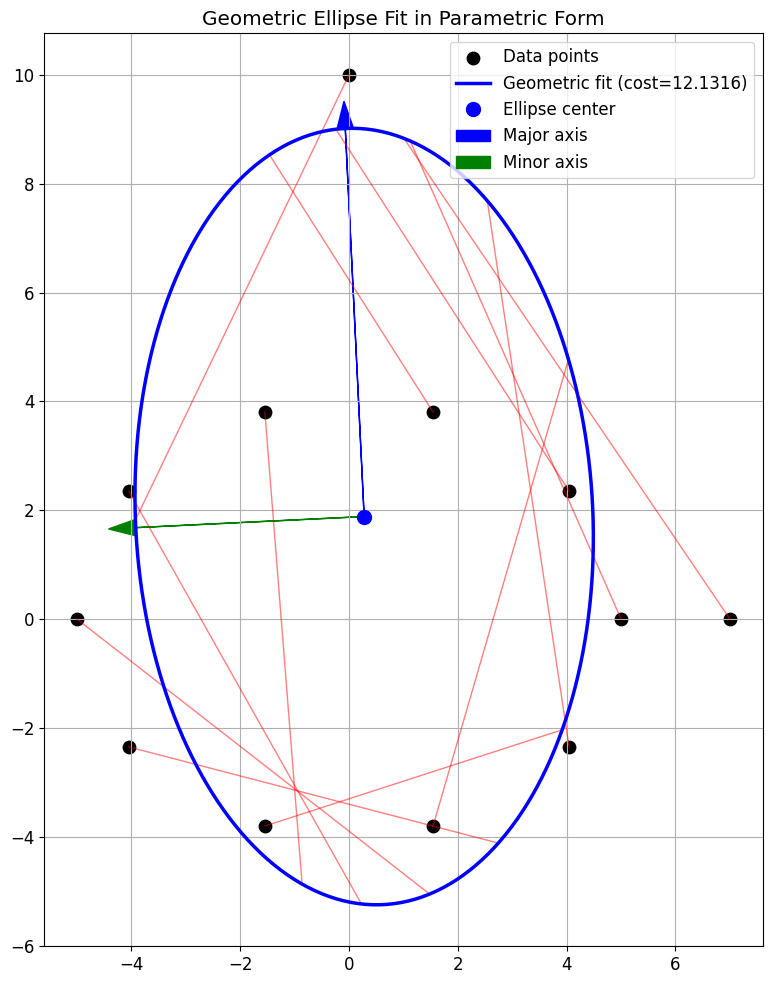

**Comparison of Ellipse Fitting Methods:**

,Method,Center_x,Center_y,Semi-major axis,Semi-minor axis,Angle (degrees),Axis ratio (a/b),Computation time (s)
0,Bookstein,-0.0000,-0.0000,nan,0.0000,-135.00,nan,0.1511
1,Trace,0.5522,1.3382,6.7345,4.5904,180.00,1.4671,0.0587
2,Geometric,0.2792,1.8830,7.1404,4.2025,92.78,1.6991,0.1059


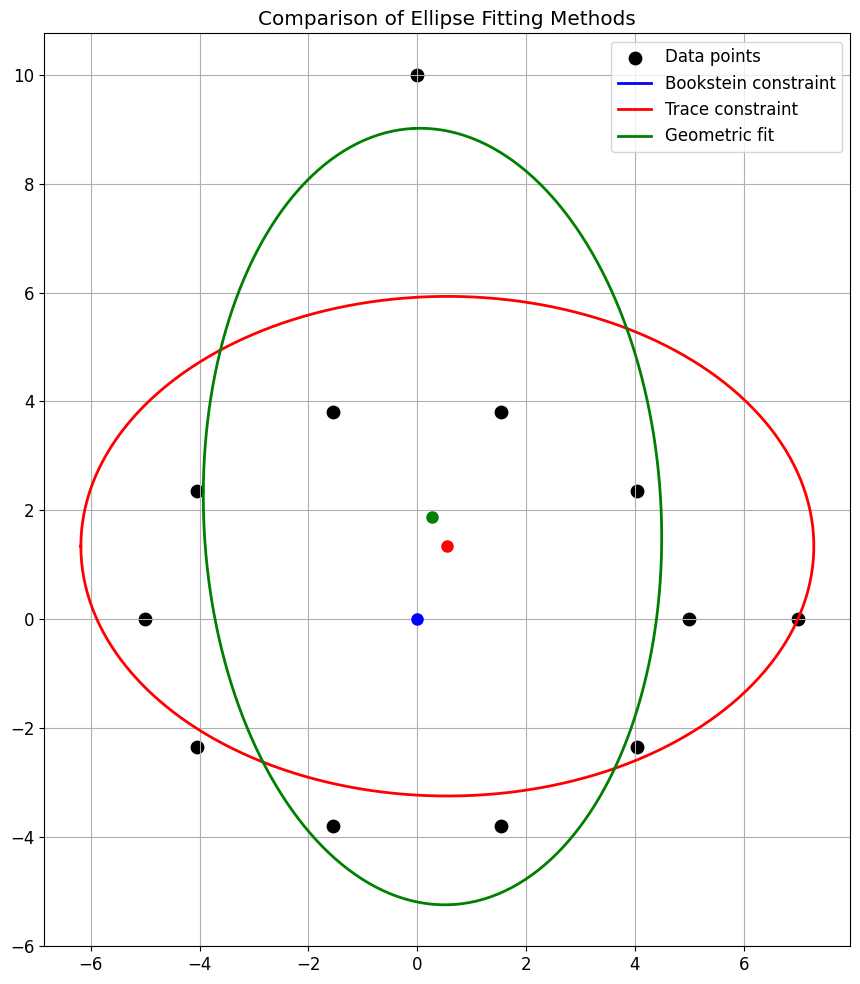

In [62]:
# Import additional required modules
import time

# Run the comparison
points = generate_sample_points()  # Use your existing sample points function
comparison_results = compare_ellipse_fits(points)

In [57]:
# Add the direct ellipse-specific fitting method
def fit_ellipse_direct(points):
    """
    Direct ellipse-specific fitting method.
    Guarantees an ellipse by using the constraint 4ac-b² > 0 directly in the eigenvalue problem.
    """
    display_step("Direct Ellipse-Specific Fitting Method")
    
    try:
        # Extract x and y coordinates
        x = points[:, 0]
        y = points[:, 1]
        
        display_points(points, "Input points")
        
        display_substep("Step 1: Build design matrix and solve constrained eigenvalue problem")
        
        # Build the design matrix D
        D = np.vstack([x**2, x*y, y**2, x, y, np.ones_like(x)]).T
        display_matrix(D[:5], "Design matrix D (first 5 rows)", 4)
        
        # Form the scatter matrix S
        S = np.dot(D.T, D)
        display_matrix(S, "Scatter matrix S", 4)
        
        # Define the constraint matrix C for ellipse-specific fitting
        # This enforces the constraint 4ac-b² > 0, which guarantees an ellipse
        C = np.zeros((6, 6))
        C[0, 2] = C[2, 0] = 2  # 2a₁₁a₂₂
        C[1, 1] = -1          # -a₁₂²
        display_matrix(C, "Constraint matrix C", 1)
        
        display_equation(r"C = \begin{bmatrix} 0 & 0 & 2 & 0 & 0 & 0 \\ 0 & -1 & 0 & 0 & 0 & 0 \\ 2 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \end{bmatrix}")
        
        # Solve the generalized eigenvalue problem S⁻¹·C·a = λa
        # We can rewrite it as S⁻¹·C·a = λa => C·a = λ·S·a
        try:
            E, V = np.linalg.eig(np.linalg.inv(S).dot(C))
            display_matrix(E, "Eigenvalues", 6)
            display_matrix(V, "Eigenvectors", 6)
            
            # Find the positive eigenvalue (for an ellipse)
            # The largest positive eigenvalue gives the best ellipse fit
            n = np.argmax(E)  # Start with maximum eigenvalue
            if E[n] <= 0:  # If maximum is not positive, try with absolute value
                n = np.argmax(np.abs(E))
                display(Markdown("**Note:** No positive eigenvalue found, using largest absolute value."))
                
            # Get the corresponding eigenvector
            a = V[:, n]
            
            # Normalize the eigenvector
            if a[0] < 0:  # Ensure a₁₁ > 0 for proper orientation
                a = -a
                
            display_matrix(a, "Selected eigenvector a", 6)
        except np.linalg.LinAlgError:
            display(Markdown("**Error:** Failed to solve eigenvalue problem. Matrix may be singular."))
            return None, None, None
            
        display_substep("Step 2: Convert conic parameters to geometric parameters")
        
        # Extract conic parameters
        a11, a12, a22, b1, b2, c = a
        a12 = a12 / 2  # Convert to standard form (a12 is doubled in the conic equation)
        b1 = b1 / 2    # Similarly for b1
        b2 = b2 / 2    # and b2
        
        display_markdown = """
        **Extracted conic parameters:**
        
        - a₁₁ = {:.6f}
        - a₁₂ = {:.6f}
        - a₂₂ = {:.6f}
        - b₁ = {:.6f}
        - b₂ = {:.6f}
        - c = {:.6f}
        
        The ellipse equation is: 
        """.format(a11, a12, a22, b1, b2, c)
        display(Markdown(display_markdown))
        display_equation(r"a_{11}x^2 + 2a_{12}xy + a_{22}y^2 + b_1x + b_2y + c = 0")
        
        # Calculate ellipse center
        # For an ellipse, the center is at (-1/2 * A⁻¹b)
        A = np.array([[a11, a12], [a12, a22]])
        b_vec = np.array([b1, b2])
        
        # Check discriminant to ensure it's an ellipse
        discriminant = 4 * a11 * a22 - 4 * a12**2
        display_parameter("Discriminant (4a₁₁a₂₂ - 4a₁₂²)", discriminant)
        
        if discriminant <= 0:
            display(Markdown("**Error:** Discriminant ≤ 0. This is not an ellipse."))
            return None, None, None
        
        try:
            center = -0.5 * np.linalg.solve(A, b_vec)
            display_matrix(center, "Ellipse center (x₀, y₀)", 6)
        except np.linalg.LinAlgError:
            display(Markdown("**Error:** Matrix A is singular. Cannot find ellipse center."))
            return None, None, None
            
        # Calculate the constant term for the centered ellipse
        c_centered = c + 0.5 * np.dot(b_vec, center) + np.dot(center, np.dot(A, center))
        display_parameter("Centered constant term c'", c_centered)
        
        # Find eigenvalues and eigenvectors of A
        eigvals, eigvecs = np.linalg.eigh(A)
        display_matrix(eigvals, "Eigenvalues of A", 6)
        display_matrix(eigvecs, "Eigenvectors of A (as columns)", 6)
        
        # Calculate the semi-axes lengths
        if c_centered >= 0:
            display(Markdown("**Warning:** c' ≥ 0. Flipping signs of all parameters."))
            c_centered = -c_centered
            eigvals = -eigvals
            
        semi_axes = np.sqrt(-c_centered / eigvals)
        display_matrix(semi_axes, "Semi-axes lengths", 6)
        
        # Calculate rotation angle
        angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
        display_parameter("Rotation angle (radians)", angle)
        display_parameter("Rotation angle (degrees)", angle * 180 / np.pi)
        
        # Ensure a ≥ b (major axis first)
        if semi_axes[0] < semi_axes[1]:
            semi_axes = semi_axes[::-1]
            angle = angle + np.pi/2
            display(Markdown("**Note:** Swapping axes to ensure a (major axis) ≥ b (minor axis)"))
            display_parameter("Updated rotation angle (radians)", angle)
            display_parameter("Updated rotation angle (degrees)", angle * 180 / np.pi)
        
        # Visualize the fitted ellipse
        display_substep("Step 3: Visualization of the fitted ellipse")
        
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Plot data points
        ax.scatter(x, y, c='black', s=80, label='Data points')
        
        # Plot the fitted ellipse
        t = np.linspace(0, 2*np.pi, 200)
        ellipse_points_curve = np.array([
            center[0] + semi_axes[0] * np.cos(t) * np.cos(angle) - semi_axes[1] * np.sin(t) * np.sin(angle),
            center[1] + semi_axes[0] * np.cos(t) * np.sin(angle) + semi_axes[1] * np.sin(t) * np.cos(angle)
        ]).T
        
        ax.plot(ellipse_points_curve[:, 0], ellipse_points_curve[:, 1], 'purple', 
                linewidth=2.5, label='Direct ellipse-specific fit')
        
        # Plot the ellipse center
        ax.plot(center[0], center[1], 'mo', markersize=10, label='Ellipse center')
        
        # Plot the axes
        ax.arrow(center[0], center[1], 
                 semi_axes[0] * np.cos(angle), semi_axes[0] * np.sin(angle), 
                 head_width=0.3, head_length=0.5, fc='m', ec='m', label='Major axis')
        
        ax.arrow(center[0], center[1], 
                 -semi_axes[1] * np.sin(angle), semi_axes[1] * np.cos(angle), 
                 head_width=0.3, head_length=0.5, fc='purple', ec='purple', label='Minor axis')
        
        ax.set_aspect('equal')
        ax.grid(True)
        ax.legend()
        ax.set_title('Direct Ellipse-Specific Fit')
        
        plt.tight_layout()
        plt.show()
        
        return center, (semi_axes[0], semi_axes[1]), angle
        
    except Exception as e:
        display(Markdown(f"**ERROR in direct ellipse fitting:** {str(e)}"))
        return None, None, None

In [69]:
# Updated comparison function with fixed plotting code
def compare_all_ellipse_fits(points):
    """
    Compare all ellipse fitting methods:
    1. Bookstein constraint (algebraic)
    2. Trace constraint (algebraic)
    3. Direct ellipse-specific (algebraic, guarantees ellipse)
    4. Geometric parametric (minimizes geometric distance)
    """
    display_step("Comparison of All Ellipse Fitting Methods")
    
    # Fit ellipses using all methods with error handling
    results_data = []
    methods = []
    
    # Bookstein method
    start_time = time.time()
    try:
        z_bookstein, axes_bookstein, angle_bookstein = fit_ellipse_bookstein_improved(points)
        time_bookstein = time.time() - start_time
        
        if z_bookstein is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Bookstein',
                'Center_x': z_bookstein[0],
                'Center_y': z_bookstein[1],
                'Semi-major axis': axes_bookstein[0],
                'Semi-minor axis': axes_bookstein[1],
                'Angle (degrees)': angle_bookstein * 180 / np.pi,
                'Axis ratio (a/b)': axes_bookstein[0] / axes_bookstein[1],
                'Computation time (s)': time_bookstein,
                'Status': 'Success'
            })
            methods.append(('Bookstein', z_bookstein, axes_bookstein, angle_bookstein, 'blue'))
        else:
            results_data.append({
                'Method': 'Bookstein',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_bookstein
            })
    except Exception as e:
        results_data.append({
            'Method': 'Bookstein',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Trace method
    start_time = time.time()
    try:
        z_trace, axes_trace, angle_trace = fit_ellipse_trace_improved(points)
        time_trace = time.time() - start_time
        
        if z_trace is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Trace',
                'Center_x': z_trace[0],
                'Center_y': z_trace[1],
                'Semi-major axis': axes_trace[0],
                'Semi-minor axis': axes_trace[1],
                'Angle (degrees)': angle_trace * 180 / np.pi,
                'Axis ratio (a/b)': axes_trace[0] / axes_trace[1],
                'Computation time (s)': time_trace,
                'Status': 'Success'
            })
            methods.append(('Trace', z_trace, axes_trace, angle_trace, 'red'))
        else:
            results_data.append({
                'Method': 'Trace',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_trace
            })
    except Exception as e:
        results_data.append({
            'Method': 'Trace',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Direct ellipse-specific method
    start_time = time.time()
    try:
        z_direct, axes_direct, angle_direct = fit_ellipse_direct(points)
        time_direct = time.time() - start_time
        
        if z_direct is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Direct',
                'Center_x': z_direct[0],
                'Center_y': z_direct[1],
                'Semi-major axis': axes_direct[0],
                'Semi-minor axis': axes_direct[1],
                'Angle (degrees)': angle_direct * 180 / np.pi,
                'Axis ratio (a/b)': axes_direct[0] / axes_direct[1],
                'Computation time (s)': time_direct,
                'Status': 'Success'
            })
            methods.append(('Direct', z_direct, axes_direct, angle_direct, 'purple'))
        else:
            results_data.append({
                'Method': 'Direct',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_direct
            })
    except Exception as e:
        results_data.append({
            'Method': 'Direct',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Geometric method
    start_time = time.time()
    try:
        z_geometric, axes_geometric, angle_geometric, cost_geometric = geometric_ellipse_fit_parametric(points)
        time_geometric = time.time() - start_time
        
        if z_geometric is not None:  # Check if the fit was successful
            results_data.append({
                'Method': 'Geometric',
                'Center_x': z_geometric[0],
                'Center_y': z_geometric[1],
                'Semi-major axis': axes_geometric[0],
                'Semi-minor axis': axes_geometric[1],
                'Angle (degrees)': angle_geometric * 180 / np.pi,
                'Axis ratio (a/b)': axes_geometric[0] / axes_geometric[1],
                'Computation time (s)': time_geometric,
                'Cost': cost_geometric,
                'Status': 'Success'
            })
            methods.append(('Geometric', z_geometric, axes_geometric, angle_geometric, 'green'))
        else:
            results_data.append({
                'Method': 'Geometric',
                'Status': 'Failed - No valid ellipse found',
                'Computation time (s)': time_geometric
            })
    except Exception as e:
        results_data.append({
            'Method': 'Geometric',
            'Status': f'Failed - {str(e)}',
            'Computation time (s)': time.time() - start_time
        })
    
    # Create DataFrame with results
    df_results = pd.DataFrame(results_data)
    display(Markdown("**Comparison of Ellipse Fitting Methods:**"))
    display(df_results)
    
    # Visualize successful fits
    if methods:  # Only plot if we have at least one successful fit
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Plot data points
        ax.scatter(points[:, 0], points[:, 1], c='black', s=80, label='Data points')
        
        # Plot ellipses for successful methods
        t = np.linspace(0, 2*np.pi, 200)
        
        for method_name, z, axes, angle, color in methods:
            # Generate ellipse points
            ellipse_curve = np.array([
                z[0] + axes[0] * np.cos(t) * np.cos(angle) - 
                        axes[1] * np.sin(t) * np.sin(angle),
                z[1] + axes[0] * np.cos(t) * np.sin(angle) + 
                        axes[1] * np.sin(t) * np.cos(angle)
            ]).T
            
            # Plot ellipse
            ax.plot(ellipse_curve[:, 0], ellipse_curve[:, 1], 
                    color=color, linewidth=2, label=f'{method_name} method')
            
            # Plot center - FIXED: Specify color separately instead of in format string
            ax.plot(z[0], z[1], 'o', color=color, markersize=8)
        
        ax.set_aspect('equal')
        ax.grid(True)
        ax.legend()
        ax.set_title('Comparison of Ellipse Fitting Methods')
        
        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("**No successful ellipse fits to visualize.**"))
    
    return df_results

## Comparison of All Ellipse Fitting Methods

## Improved Bookstein Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,0.5833,0.8333


**Original points:**

,x,y
Point 1,0.0000,10.0000
Point 2,7.0000,0.0000
Point 3,5.0000,0.0000
Point 4,4.0451,2.3511
Point 5,1.5451,3.8042
Point 6,-1.5451,3.8042
Point 7,-4.0451,2.3511
Point 8,-5.0000,0.0000
Point 9,-4.0451,-2.3511
Point 10,-1.5451,-3.8042


**Centered points:**

,x,y
Point 1,-0.5833,9.1667
Point 2,6.4167,-0.8333
Point 3,4.4167,-0.8333
Point 4,3.4618,1.5178
Point 5,0.9618,2.9709
Point 6,-2.1284,2.9709
Point 7,-4.6284,1.5178
Point 8,-5.5833,-0.8333
Point 9,-4.6284,-3.1844
Point 10,-2.1284,-4.6375


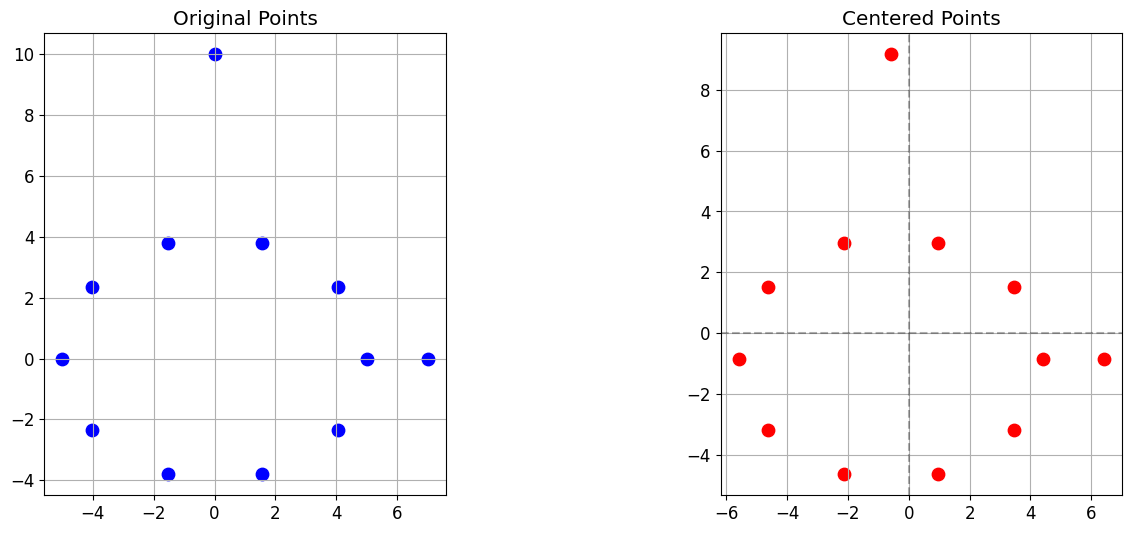

### Step 2: Create the design matrix

**Design Matrix B (first 5 rows):**

,0,1,2,3,4,5
0,-0.5833,9.1667,1.0000,0.3403,-7.5621,84.0278
1,6.4167,-0.8333,1.0000,41.1736,-7.5621,0.6944
2,4.4167,-0.8333,1.0000,19.5069,-5.2051,0.6944
3,3.4618,1.5178,1.0000,11.9838,7.4305,2.3036
4,0.9618,2.9709,1.0000,0.9250,4.0408,8.8260


### Step 3: QR Decomposition

**R Matrix:**

...

**Semi-minor axis b:** 0.000000

**Rotation angle α (radians):** -2.356194

**Rotation angle α (degrees):** -135.000000

**Final center z in original coordinates:**

,0,1
0,-0.000000,-0.000000


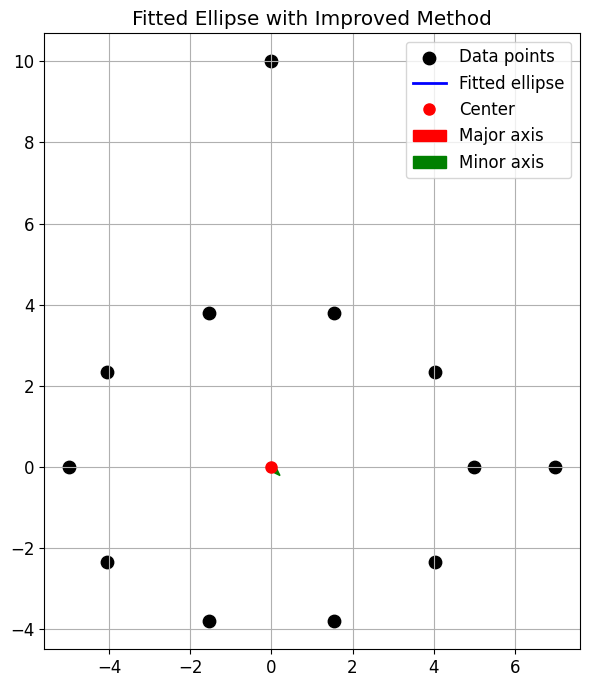

## Improved Trace Constraint Method

### Step 1: Center the data

**Centroid:**

,0,1
0,0.5833,0.8333


### Step 2: Create design matrix for trace constraint

...

**Semi-minor axis b:** 4.590407

**Rotation angle α (radians):** 3.141593

**Rotation angle α (degrees):** 180.000000

**Final center z in original coordinates:**

,0,1
0,0.552173,1.338152


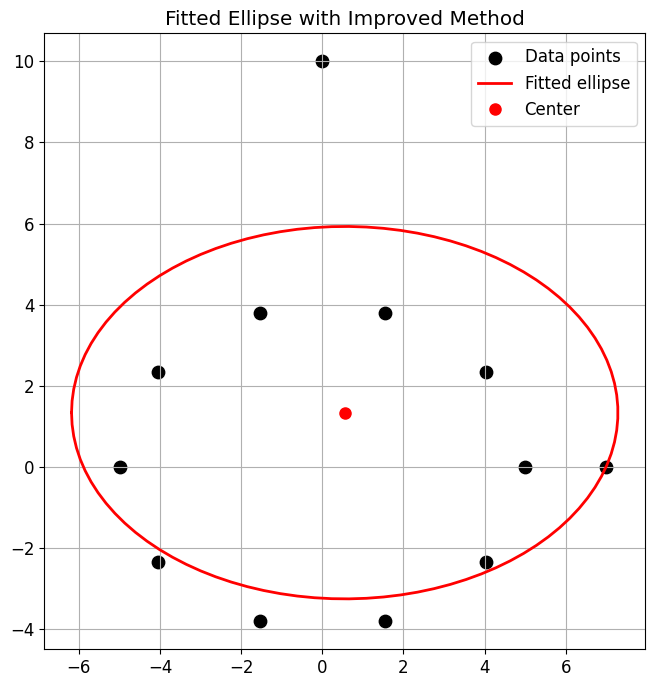

## Direct Ellipse-Specific Fitting Method

**Input points:**

,x,y
Point 1,0.0000,10.0000
Point 2,7.0000,0.0000
Point 3,5.0000,0.0000
Point 4,4.0451,2.3511
Point 5,1.5451,3.8042
Point 6,-1.5451,3.8042
Point 7,-4.0451,2.3511
Point 8,-5.0000,0.0000
Point 9,-4.0451,-2.3511
Point 10,-1.5451,-3.8042


### Step 1: Build design matrix and solve constrained eigenvalue problem

**Design matrix D (first 5 rows):**

...

**Semi-axes lengths:**

,0,1
0,5.724618,4.663714


**Rotation angle (radians):** 1.570796

**Rotation angle (degrees):** 90.000000

### Step 3: Visualization of the fitted ellipse

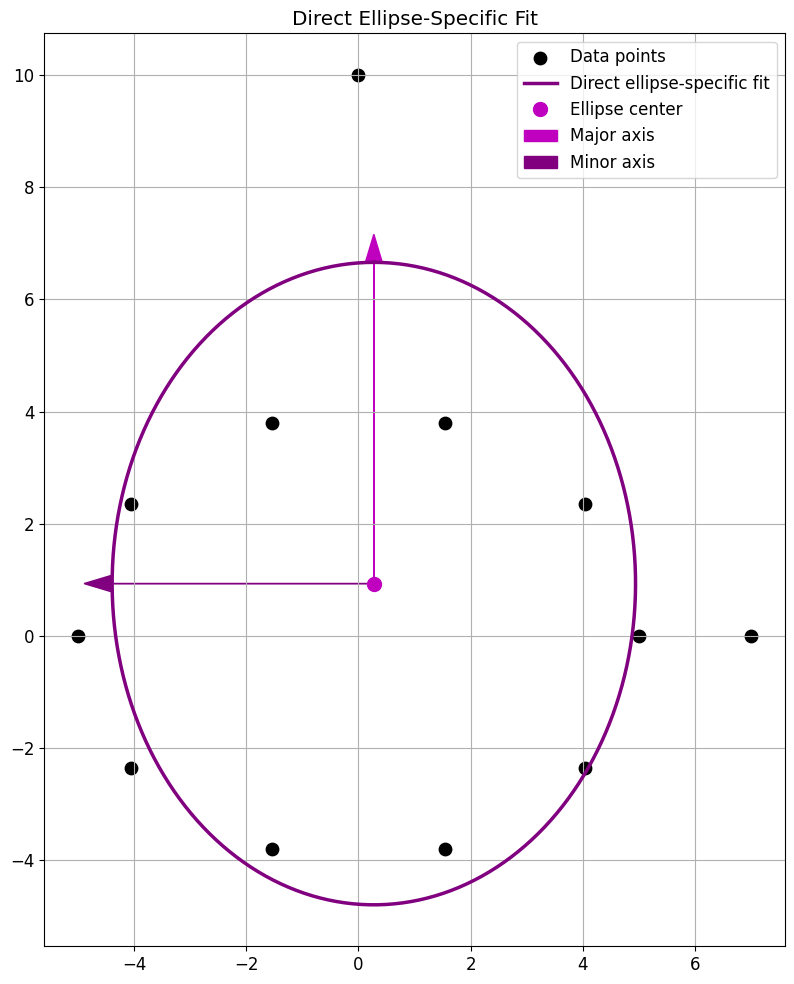

## Geometric Ellipse Fitting in Parametric Form

**Input points:**

,x,y
Point 1,0.0000,10.0000
Point 2,7.0000,0.0000
Point 3,5.0000,0.0000
Point 4,4.0451,2.3511
Point 5,1.5451,3.8042
Point 6,-1.5451,3.8042
Point 7,-4.0451,2.3511
Point 8,-5.0000,0.0000
Point 9,-4.0451,-2.3511
Point 10,-1.5451,-3.8042


### Step 1: Get initial parameters using algebraic fit

**Initial center x₀:** 0.583333

...

**Mean distance from points to ellipse:** 8.360645

**Maximum distance from points to ellipse:** 10.673134

**Distances from points to the fitted ellipse:**

,x,y,distance
Point 1,0.0000,10.0000,9.0735
Point 2,7.0000,0.0000,10.6731
Point 3,5.0000,0.0000,9.6004
Point 4,4.0451,2.3511,7.9108
Point 5,1.5451,3.8042,5.6005
Point 6,-1.5451,3.8042,8.7030
Point 7,-4.0451,2.3511,8.7091
Point 8,-5.0000,0.0000,8.2200
Point 9,-4.0451,-2.3511,7.0163
Point 10,-1.5451,-3.8042,5.7424


### Step 5: Visualization of the fitted ellipse

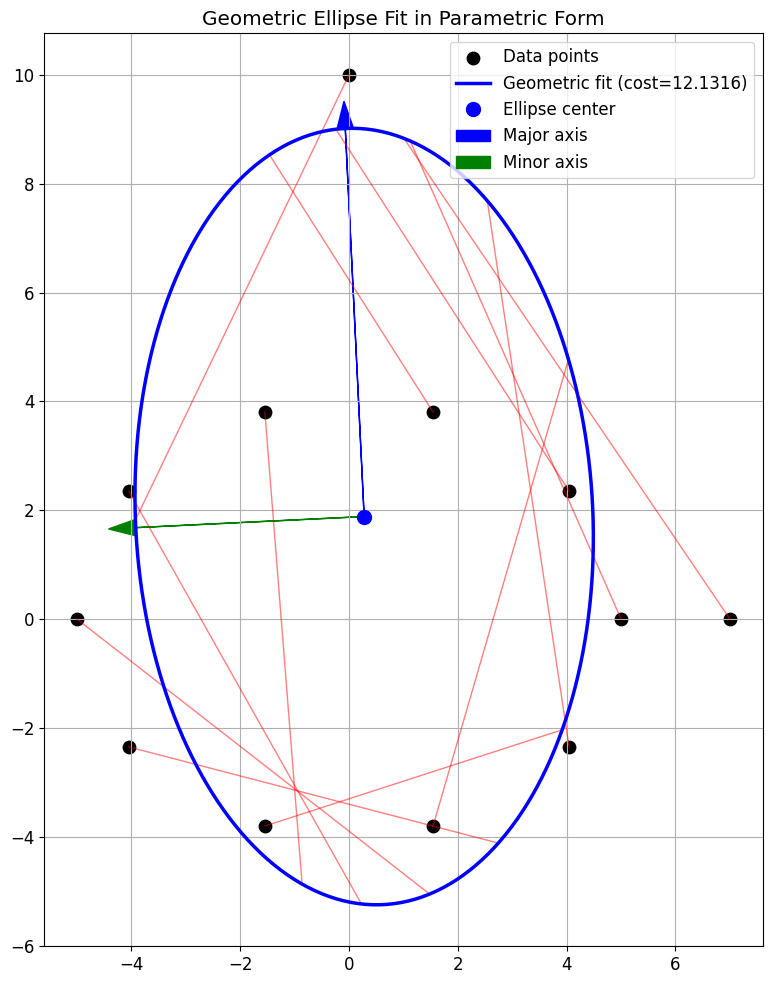

**Comparison of Ellipse Fitting Methods:**

,Method,Center_x,Center_y,Semi-major axis,Semi-minor axis,Angle (degrees),Axis ratio (a/b),Computation time (s),Status,Cost
0,Bookstein,-6.661338e-16,-2.220446e-16,NaN,5.316170e-08,-135.000000,NaN,0.153518,Success,NaN
1,Trace,5.521725e-01,1.338152e+00,6.734518,4.590407e+00,180.000000,1.467085,0.068731,Success,NaN
2,Direct,2.740628e-01,9.337408e-01,5.724618,4.663714e+00,90.000000,1.227481,0.074585,Success,NaN
3,Geometric,2.792157e-01,1.882970e+00,7.140420,4.202493e+00,92.783621,1.699092,0.090422,Success,12.131646


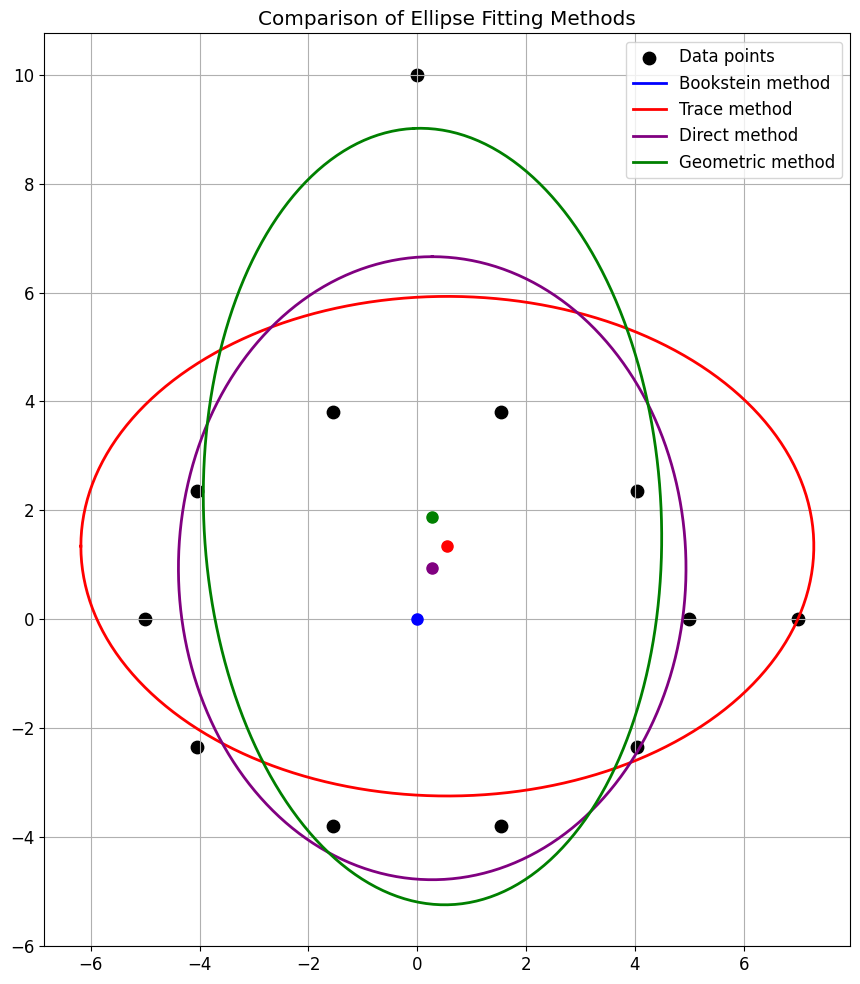

In [70]:

# Run all methods and compare
full_comparison = compare_all_ellipse_fits(points)